<a href="https://colab.research.google.com/github/RajolKumar2003/Computer-Log-Anomaly-Detection/blob/dataset-code/Large_Dataset_Contamination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports the necessary libraries, pandas for data manipulation and numpy for numerical operations.

In [ ]:
import pandas as pd
import numpy as np

This cell mounts the Google Drive to access files stored there, ensuring the notebook can read the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell defines the file path for the dataset located in Google Drive and prints it for verification.

In [ ]:
file_path = '/content/drive/MyDrive/02-15-2018.csv'

print("Dataset path:")
print(file_path)

Dataset path:
/content/drive/MyDrive/02-15-2018.csv


This cell loads the dataset from the specified CSV file path into a pandas DataFrame. The `low_memory=False` option is used to prevent potential DtypeWarning.

In [ ]:
print("Loading dataset...")

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")

Loading dataset...
Dataset loaded successfully.


This cell displays the first 5 rows of the loaded DataFrame to give a quick overview of the data.

In [ ]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


This cell retrieves and displays a list of all column names in the DataFrame, which is useful for understanding the available features.

In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

This cell provides a concise summary of the DataFrame, including the column names, their non-null counts, and data types, along with memory usage.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

This cell removes the 'Timestamp' column from the DataFrame as it's not needed for the subsequent analysis.

In [ ]:
df.drop('Timestamp', axis=1, inplace=True)
print("'Timestamp' column removed successfully.")

'Timestamp' column removed successfully.


This cell generates and displays a pie chart showing the distribution of different labels in the dataset, providing a visual representation of class imbalance.

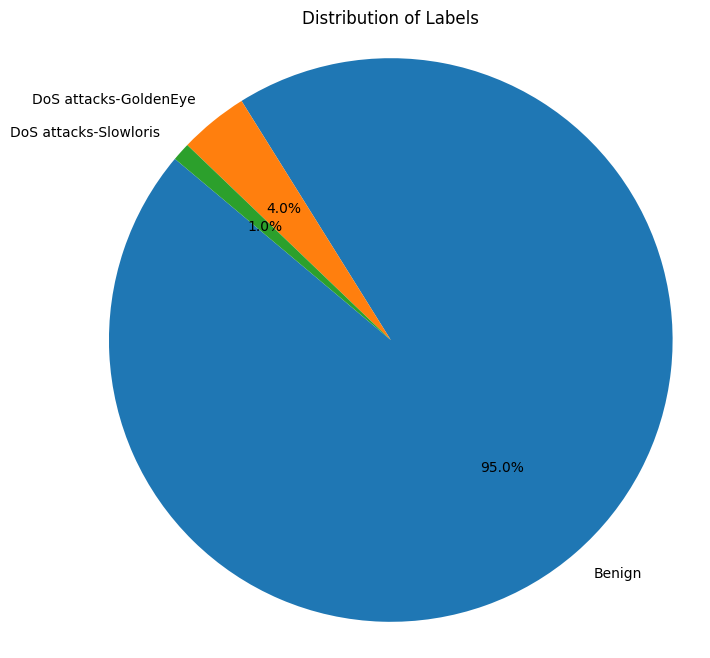

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell filters out rows where the 'Label' is 'DoS attacks-Slowloris', indicating the removal of a specific type of attack from the dataset.

In [ ]:
initial_rows = len(df)
df = df[df['Label'] != 'DoS attacks-Slowloris']
removed_rows = initial_rows - len(df)
print(f"Removed {removed_rows} rows labeled 'DoS attacks-Slowloris'.")
print(f"New DataFrame shape: {df.shape}")

Removed 10990 rows labeled 'DoS attacks-Slowloris'.
New DataFrame shape: (1037585, 79)


This cell regenerates and displays a pie chart of the label distribution after removing 'DoS attacks-Slowloris' rows, showing both counts and percentages.

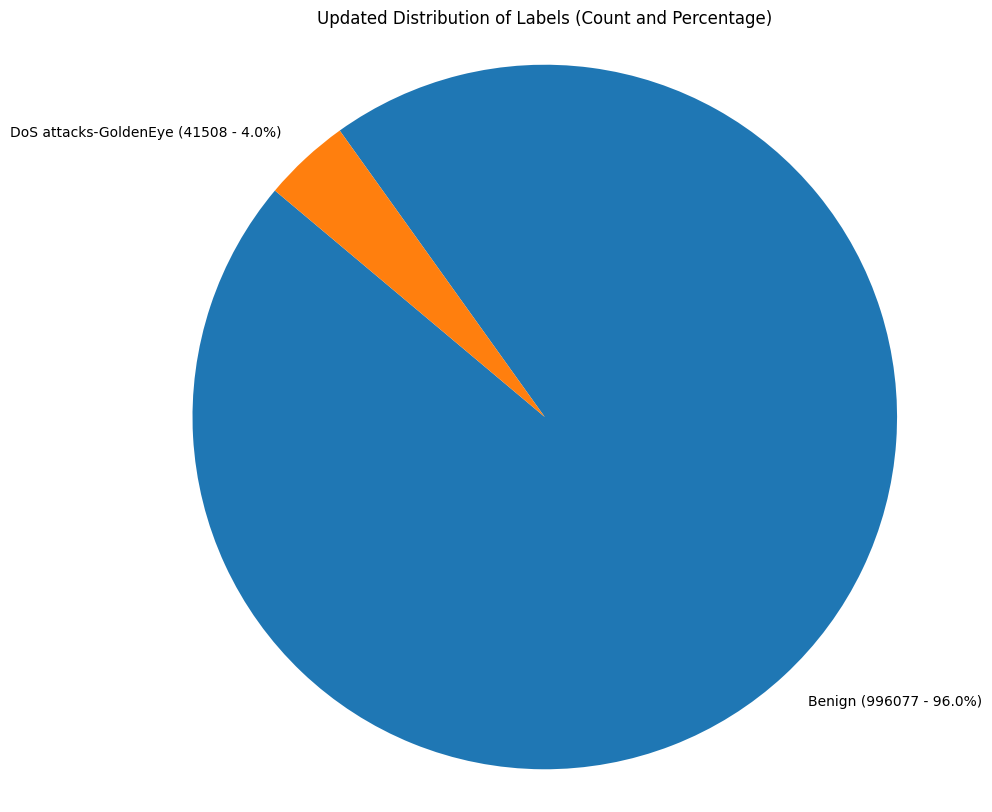

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell calculates and prints the number and percentage of duplicate rows in the DataFrame.

In [ ]:
duplicate_rows = df.duplicated().sum()
total_rows = len(df)
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Total number of rows: {total_rows}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 162835
Total number of rows: 1037585
Percentage of duplicate rows: 15.69%


This cell displays all the duplicate records found in the DataFrame.

In [ ]:
print("Duplicate records:")
duplicate_records = df[df.duplicated()]
display(duplicate_records)

Duplicate records:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
12290,80,6,1968873,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13026,80,6,1947540,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13146,80,6,9003609,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9003609.0,0.0,9003609,9003609,DoS attacks-GoldenEye
13392,80,6,9000561,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9000561.0,0.0,9000561,9000561,DoS attacks-GoldenEye
14374,80,6,1954456,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048478,80,6,113,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048488,443,6,142,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048490,80,6,97,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048553,443,6,219,3,0,77,0,46,0,25.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


This cell removes all duplicate rows from the DataFrame, keeping only the first occurrence.

In [ ]:
print("Removing duplicate rows...")
df.drop_duplicates(inplace=True)
print(f"DataFrame now has {len(df)} distinct rows.")

Removing duplicate rows...
DataFrame now has 874750 distinct rows.


This cell identifies and displays the count of missing values for each column in the DataFrame.

In [ ]:
print("Missing values in the DataFrame:")
missing_values = df.isnull().sum()
# Display only columns with missing values
display(missing_values[missing_values > 0])

Missing values in the DataFrame:


,0
Flow Byts/s,4759


This cell calculates and displays the percentage of missing values for each column in the DataFrame.

In [ ]:
print("Percentage of missing values in the DataFrame:")
missing_percentage = (missing_values / len(df)) * 100
# Display only columns with missing values and their percentages
display(missing_percentage[missing_percentage > 0])

Percentage of missing values in the DataFrame:


,0
Flow Byts/s,0.544041


This cell handles missing values in the 'Flow Byts/s' column by imputing them with the median value grouped by their respective 'Label'.

In [ ]:
# Check labels associated with missing 'Flow Byts/s' values
print("Labels for rows with missing 'Flow Byts/s' values:")
display(df[df['Flow Byts/s'].isnull()]['Label'].value_counts())

# Calculate median 'Flow Byts/s' for each label
median_flow_byts_per_label = df.groupby('Label')['Flow Byts/s'].median()
print("\nMedian 'Flow Byts/s' for each label:")
display(median_flow_byts_per_label)

# Impute missing 'Flow Byts/s' values based on the median of their respective label
for label, median_value in median_flow_byts_per_label.items():
    df.loc[(df['Label'] == label) & (df['Flow Byts/s'].isnull()), 'Flow Byts/s'] = median_value

print("\nMissing values in 'Flow Byts/s' imputed successfully.")
# Verify that there are no more missing values in 'Flow Byts/s'
print("\nMissing values after imputation:")
display(df['Flow Byts/s'].isnull().sum())


Labels for rows with missing 'Flow Byts/s' values:


,count
Label,
Benign,4759



Median 'Flow Byts/s' for each label:


,Flow Byts/s
Label,
Benign,1035.553257
DoS attacks-GoldenEye,122.482045



Missing values in 'Flow Byts/s' imputed successfully.

Missing values after imputation:


np.int64(0)

This cell identifies and handles infinite values in numeric columns by replacing them with NaNs and then imputing these NaNs with the median grouped by 'Label'.

In [ ]:
print("Checking for and handling infinite values...")

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Check for infinite values in numeric columns
inf_mask = df[numeric_cols].isin([np.inf, -np.inf]).any(axis=1)

if inf_mask.any():
    print("\nRows with infinite values detected. Displaying 'Label' distribution for these rows:")
    # Display value counts of 'Label' for rows with infinite values
    display(df.loc[inf_mask, 'Label'].value_counts())

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Identify columns that now have NaN values (originally Inf)
    missing_from_inf_cols = df.columns[df.isnull().any()].tolist()
    missing_from_inf_cols = [col for col in missing_from_inf_cols if col in numeric_cols] # Only consider numeric cols for imputation

    if missing_from_inf_cols:
        print("\nColumns with NaN values (originally Inf) identified:")
        print(missing_from_inf_cols)

        # Impute these new NaN values with the median of their respective columns, grouped by 'Label'
        print("\nImputing NaN values (originally Inf) with median, grouped by 'Label'...")
        for col in missing_from_inf_cols:
            # Calculate median grouped by 'Label'
            median_by_label = df.groupby('Label')[col].transform('median')
            # Fill NaN values using the calculated median specific to each label
            df.loc[:, col] = df.loc[:, col].fillna(median_by_label)
            print(f"  - Imputed column '{col}' with label-wise medians.")
        print("\nInfinite values handled and imputed with label-wise medians successfully.")
    else:
        print("No columns had infinite values that turned into NaNs.")
else:
    print("No infinite values found in the DataFrame.")

# Verify that there are no more missing values introduced by Inf handling
print("\nRemaining missing values after handling Inf:")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    display(remaining_missing)
else:
    print("No remaining missing values.")

Checking for and handling infinite values...

Rows with infinite values detected. Displaying 'Label' distribution for these rows:


,count
Label,
Benign,7712



Columns with NaN values (originally Inf) identified:
['Flow Byts/s', 'Flow Pkts/s']

Imputing NaN values (originally Inf) with median, grouped by 'Label'...
  - Imputed column 'Flow Byts/s' with label-wise medians.
  - Imputed column 'Flow Pkts/s' with label-wise medians.

Infinite values handled and imputed with label-wise medians successfully.

Remaining missing values after handling Inf:
No remaining missing values.


This cell generates an updated pie chart showing the distribution of labels (including counts and percentages) after all data cleaning steps.

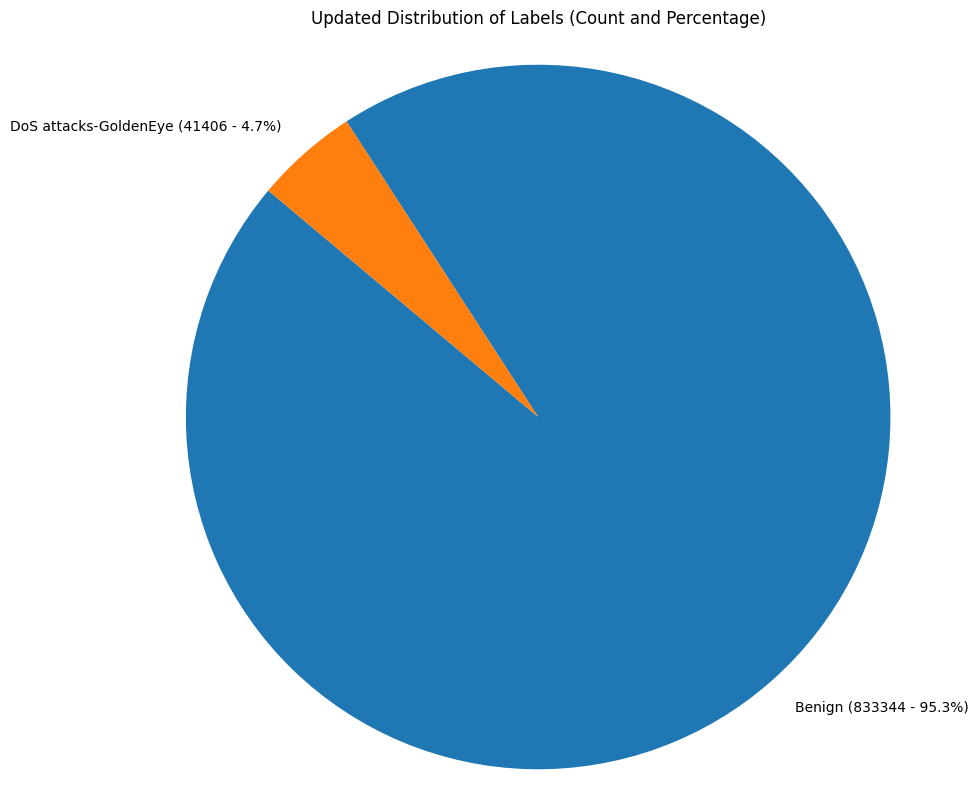

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell preprocesses the data by separating benign and attack records, then creating stratified training and testing datasets for different anomaly rates (0.2%, 1%, 5%). It also verifies the disjoint nature and hierarchical structure of the generated datasets.

In [ ]:
import pandas as pd
import numpy as np
import gc # Import garbage collector

RANDOM_STATE = 42

# Separate benign and attack records from the main DataFrame
benign_records = df[df['Label'] == 'Benign'].copy()
attack_records_goldeneye = df[df['Label'] == 'DoS attacks-GoldenEye'].copy()

print("==================================================")
print("TEST DATA CREATION - BENIGN SAMPLES")
print("==================================================")

N_total_test_size = 50000 # Total size for each test dataset

# Calculate required benign and anomaly counts for each anomaly rate
# For 0.2% anomaly:
N_anomaly_02 = round(N_total_test_size * 0.002)
N_benign_02 = N_total_test_size - N_anomaly_02

# For 1% anomaly:
N_anomaly_1 = round(N_total_test_size * 0.01)
N_benign_1 = N_total_test_size - N_anomaly_1

# For 5% anomaly:
N_anomaly_5 = round(N_total_test_size * 0.05)
N_benign_5 = N_total_test_size - N_anomaly_5

# To ensure "benign data should be common" in the sense of hierarchy (smaller subsets are part of larger),
# we need to sample the largest required benign set first.
max_benign_samples_for_test = max(N_benign_02, N_benign_1, N_benign_5)

# Sample the largest required number of benign samples for the test sets from the available benign records
sampled_benign_for_test = benign_records.sample(n=max_benign_samples_for_test, random_state=RANDOM_STATE)
common_test_benign_pool_original_indices = sampled_benign_for_test.index # Store original indices for non-overlap
common_test_benign_pool_sampled = sampled_benign_for_test.reset_index(drop=True)

del sampled_benign_for_test
gc.collect()

# Create the hierarchical benign test sets by slicing the sampled pool
test_benign_02_percent = common_test_benign_pool_sampled.iloc[:N_benign_02].copy()
test_benign_1_percent = common_test_benign_pool_sampled.iloc[:N_benign_1].copy()
test_benign_5_percent = common_test_benign_pool_sampled.iloc[:N_benign_5].copy()

print(f"Benign test set for 0.2% attacks ({N_benign_02} samples) shape: {test_benign_02_percent.shape}")
print(f"Benign test set for 1% attacks ({N_benign_1} samples) shape: {test_benign_1_percent.shape}")
print(f"Benign test set for 5% attacks ({N_benign_5} samples) shape: {test_benign_5_percent.shape}")

del common_test_benign_pool_sampled
gc.collect()

# Determine the maximum anomaly samples needed to create a superset for attack hierarchy for test sets
max_anomaly_samples_for_test = max(N_anomaly_02, N_anomaly_1, N_anomaly_5)

# Randomly sample the superset of DoS-GoldenEye records for all test attack levels
sampled_attacks_for_test = attack_records_goldeneye.sample(n=max_anomaly_samples_for_test, random_state=RANDOM_STATE)
test_attack_original_indices = sampled_attacks_for_test.index # Store original indices for non-overlap
attack_samples_level3_superset = sampled_attacks_for_test.reset_index(drop=True)

del sampled_attacks_for_test
gc.collect()

# Create hierarchical attack sets by slicing the superset and assigning labels
attacks_L1 = attack_samples_level3_superset.iloc[:N_anomaly_02].copy()
attacks_L1['Label'] = 1

attacks_L2_full = attack_samples_level3_superset.iloc[:N_anomaly_1].copy()
attacks_L2_full.loc[attacks_L2_full.index < N_anomaly_02, 'Label'] = 1
attacks_L2_full.loc[attacks_L2_full.index >= N_anomaly_02, 'Label'] = 2

attacks_L3_full = attack_samples_level3_superset.iloc[:N_anomaly_5].copy()
attacks_L3_full.loc[attacks_L3_full.index < N_anomaly_02, 'Label'] = 1
attacks_L3_full.loc[(attacks_L3_full.index >= N_anomaly_02) & (attacks_L3_full.index < N_anomaly_1), 'Label'] = 2
attacks_L3_full.loc[attacks_L3_full.index >= N_anomaly_1, 'Label'] = 3

print(f"Attack samples for 0.2% dataset (L1, {attacks_L1.shape[0]} samples) shape: {attacks_L1.shape}")
print(f"Attack samples for 1% dataset (L1+L2, {attacks_L2_full.shape[0]} samples) shape: {attacks_L2_full.shape}")
print(f"Attack samples for 5% dataset (L1+L2+L3, {attacks_L3_full.shape[0]} samples) shape: {attacks_L3_full.shape}")

del attack_samples_level3_superset
gc.collect()

# 4. Construct Final Test Datasets (total 50k samples each)
test_df_02 = pd.concat([test_benign_02_percent, attacks_L1]).reset_index(drop=True)
test_df_1 = pd.concat([test_benign_1_percent, attacks_L2_full]).reset_index(drop=True)
test_df_5 = pd.concat([test_benign_5_percent, attacks_L3_full]).reset_index(drop=True)

# Clean up intermediate test dataframes
del test_benign_02_percent, test_benign_1_percent, test_benign_5_percent
del attacks_L1, attacks_L2_full, attacks_L3_full
gc.collect()

print("\nTest dataset shapes:")
print(f"  0.2% Test dataset shape: {test_df_02.shape}")
print(f"  1% Test dataset shape: {test_df_1.shape}")
print(f"  5% Test dataset shape: {test_df_5.shape}")

print("\nClass distributions:")
print("  0.2% Test dataset class distribution:\n" + str(test_df_02['Label'].value_counts()))
print("  1% Test dataset class distribution:\n" + str(test_df_1['Label'].value_counts()))
print("  5% Test dataset class distribution:\n" + str(test_df_5['Label'].value_counts()))

print("\nPercentage distributions:")
print("  0.2% Test dataset percentage distribution:\n" + str(test_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Test dataset percentage distribution:\n" + str(test_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Test dataset percentage distribution:\n" + str(test_df_5['Label'].value_counts(normalize=True) * 100))

print("\n==================================================")
print("TRAINING DATA CREATION - REMAINING SAMPLES")
print("==================================================")

# Identify benign records not used in test sets for training
train_benign_pool_all = benign_records[~benign_records.index.isin(common_test_benign_pool_original_indices)].copy()
# Identify attack records not used in test sets for training
train_attack_pool_all = attack_records_goldeneye[~attack_records_goldeneye.index.isin(test_attack_original_indices)].copy()

# Calculate the actual number of available benign and attack samples for training
available_benign_for_train = len(train_benign_pool_all)
available_attack_for_train = len(train_attack_pool_all)

# Determine the maximum total training size that can be achieved for the 5% anomaly rate
# given the available attack samples and benign samples. This will be the common size for all train sets.
max_total_size_by_attack_limit = available_attack_for_train / 0.05 if 0.05 > 0 else float('inf')
max_total_size_by_benign_limit = available_benign_for_train / 0.95 if 0.95 > 0 else float('inf')

# The N_total_train_size should be the minimum of these limits, rounded down.
# This ensures that all required benign and anomaly samples can be drawn for all anomaly rates.
N_total_train_size = int(min(max_total_size_by_attack_limit, max_total_size_by_benign_limit))

print(f"Adjusted N_total_train_size to ensure all train datasets have the same size and proportions: {N_total_train_size}")

# Calculate required benign and anomaly counts for each anomaly rate for training sets
train_N_anomaly_02 = round(N_total_train_size * 0.002)
train_N_benign_02 = N_total_train_size - train_N_anomaly_02

train_N_anomaly_1 = round(N_total_train_size * 0.01)
train_N_benign_1 = N_total_train_size - train_N_anomaly_1

train_N_anomaly_5 = round(N_total_train_size * 0.05)
train_N_benign_5 = N_total_train_size - train_N_anomaly_5

# To ensure "benign data should be common" in the sense of hierarchy for training,
# we need to sample the largest required benign set first from the available training benign pool.
train_max_benign_samples = train_N_benign_02 # This is the largest benign count needed

# Sample indices from the available training benign pool
common_train_benign_pool_sampled_indices = train_benign_pool_all.sample(n=train_max_benign_samples, random_state=RANDOM_STATE).index

# Create hierarchical benign training sets using loc and reset_index once
train_benign_02_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_02]].reset_index(drop=True)
train_benign_1_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_1]].reset_index(drop=True)
train_benign_5_percent = train_benign_pool_all.loc[common_train_benign_pool_sampled_indices[:train_N_benign_5]].reset_index(drop=True)

print(f"Benign train set for 0.2% attacks ({train_N_benign_02} samples) shape: {train_benign_02_percent.shape}")
print(f"Benign train set for 1% attacks ({train_N_benign_1} samples) shape: {train_benign_1_percent.shape}")
print(f"Benign train set for 5% attacks ({train_N_benign_5} samples) shape: {train_benign_5_percent.shape}")

del common_train_benign_pool_sampled_indices, train_benign_pool_all
gc.collect()

# Determine the maximum anomaly samples needed for training (for 5% anomaly rate)
train_max_anomaly_samples = train_N_anomaly_5

# Sample the superset of DoS-GoldenEye records for all training attack levels
train_attack_samples_superset = train_attack_pool_all.sample(n=train_max_anomaly_samples, random_state=RANDOM_STATE).reset_index(drop=True)

# These are already the "actual" counts because N_total_train_size was adjusted
train_N_anomaly_02_actual = train_N_anomaly_02
train_N_anomaly_1_actual = train_N_anomaly_1
train_N_anomaly_5_actual = train_N_anomaly_5

# Level 1 attacks for training: train_N_anomaly_02_actual records, labeled 1
train_attacks_L1 = train_attack_samples_superset.iloc[:train_N_anomaly_02_actual].copy()
train_attacks_L1['Label'] = 1

# Level 2 attacks for training: Total train_N_anomaly_1_actual records, labeled 2 (additional) or 1 (from L1)
train_attacks_L2_full = train_attack_samples_superset.iloc[:train_N_anomaly_1_actual].copy()
train_attacks_L2_full.loc[train_attacks_L2_full.index < train_N_anomaly_02_actual, 'Label'] = 1
train_attacks_L2_full.loc[train_attacks_L2_full.index >= train_N_anomaly_02_actual, 'Label'] = 2

# Level 3 attacks for training: Total train_N_anomaly_5_actual records, labeled 3 (additional) or 1/2 (from L1/L2)
train_attacks_L3_full = train_attack_samples_superset.iloc[:train_N_anomaly_5_actual].copy()
train_attacks_L3_full.loc[train_attacks_L3_full.index < train_N_anomaly_02_actual, 'Label'] = 1
train_attacks_L3_full.loc[(train_attacks_L3_full.index >= train_N_anomaly_02_actual) & (train_attacks_L3_full.index < train_N_anomaly_1_actual), 'Label'] = 2
train_attacks_L3_full.loc[train_attacks_L3_full.index >= train_N_anomaly_1_actual, 'Label'] = 3

print(f"Attack samples for 0.2% train dataset (L1, {train_attacks_L1.shape[0]} samples) shape: {train_attacks_L1.shape}")
print(f"Attack samples for 1% train dataset (L1+L2, {train_attacks_L2_full.shape[0]} samples) shape: {train_attacks_L2_full.shape}")
print(f"Attack samples for 5% train dataset (L1+L2+L3, {train_attacks_L3_full.shape[0]} samples) shape: {train_attacks_L3_full.shape}")

del train_attack_samples_superset, train_attack_pool_all
gc.collect()

# Construct Final Training Datasets (total N_total_train_size samples each)
train_df_02 = pd.concat([train_benign_02_percent, train_attacks_L1]).reset_index(drop=True)
train_df_1 = pd.concat([train_benign_1_percent, train_attacks_L2_full]).reset_index(drop=True)
train_df_5 = pd.concat([train_benign_5_percent, train_attacks_L3_full]).reset_index(drop=True)

# Clean up intermediate training dataframes
del train_benign_02_percent, train_benign_1_percent, train_benign_5_percent
del train_attacks_L1, train_attacks_L2_full, train_attacks_L3_full

del benign_records, attack_records_goldeneye # Delete the initial large DFs once no longer needed
gc.collect()

print("\nTrain dataset shapes:")
print(f"  0.2% Train dataset shape: {train_df_02.shape}")
print(f"  1% Train dataset shape: {train_df_1.shape}")
print(f"  5% Train dataset shape: {train_df_5.shape}")

print("\nTrain Class distributions:")
print("  0.2% Train dataset class distribution:\n" + str(train_df_02['Label'].value_counts()))
print("  1% Train dataset class distribution:\n" + str(train_df_1['Label'].value_counts()))
print("  5% Train dataset class distribution:\n" + str(train_df_5['Label'].value_counts()))

print("\nTrain Percentage distributions:")
print("  0.2% Train dataset percentage distribution:\n" + str(train_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Train dataset percentage distribution:\n" + str(train_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Train dataset percentage distribution:\n" + str(train_df_5['Label'].value_counts(normalize=True) * 100))


print("\n==================================================")
print("VERIFICATION")
print("==================================================")

# Verification that train and test normal samples are disjoint
overlap_train_test_benign = pd.merge(train_df_02[train_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore'),
                                     test_df_02[test_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore'),
                                     how='inner', on=list(df.drop(columns=['Label'], errors='ignore').columns)).shape[0]
print(f"Overlap between training benign and largest test benign set: {overlap_train_test_benign} records. (Expected: 0)")

# Verification that benign test records are identical across test datasets (hierarchical requirement)
# To verify hierarchy, we need to compare the actual benign samples. Re-extract them from final DFs.
re_test_benign_02 = test_df_02[test_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_test_benign_1 = test_df_1[test_df_1['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_test_benign_5 = test_df_5[test_df_5['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')

is_5_in_1 = re_test_benign_5.shape[0] == pd.merge(re_test_benign_5, re_test_benign_1, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_1_in_02 = re_test_benign_1.shape[0] == pd.merge(re_test_benign_1, re_test_benign_02, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all {re_test_benign_5.shape[0]} benign samples in {re_test_benign_1.shape[0]} benign samples? {is_5_in_1}")
print(f"Are all {re_test_benign_1.shape[0]} benign samples in {re_test_benign_02.shape[0]} benign samples? {is_1_in_02}")

# Verification that attack hierarchy is satisfied for test sets
# Re-extract attacks with their original labels from the final DFs for verification
re_test_attacks_L1 = test_df_02[test_df_02['Label'] == 1].drop(columns=['Label'], errors='ignore')
re_test_attacks_L2_full = test_df_1[test_df_1['Label'].isin([1,2])].drop(columns=['Label'], errors='ignore')
re_test_attacks_L3_full = test_df_5[test_df_5['Label'].isin([1,2,3])].drop(columns=['Label'], errors='ignore')

is_L1_in_L2_test = re_test_attacks_L1.shape[0] == pd.merge(re_test_attacks_L1, re_test_attacks_L2_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3_test = re_test_attacks_L2_full.shape[0] == pd.merge(re_test_attacks_L2_full, re_test_attacks_L3_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks (Test)? {is_L1_in_L2_test}")
print(f"Are all Level 2 attacks in Level 3 attacks (Test)? {is_L2_in_L3_test}")

# Verify attack labels within each test dataset
print("\nAttack label verification (Test sets):")
print(f"  Labels in 0.2% test attacks: {test_df_02[test_df_02['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 1% test attacks: {test_df_1[test_df_1['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 5% test attacks: {test_df_5[test_df_5['Label'] != 'Benign']['Label'].unique()}")

# Verification that benign training records are identical across train datasets (hierarchical requirement)
# Re-extract them from final DFs for verification.
re_train_benign_02 = train_df_02[train_df_02['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_train_benign_1 = train_df_1[train_df_1['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')
re_train_benign_5 = train_df_5[train_df_5['Label'] == 'Benign'].drop(columns=['Label'], errors='ignore')

is_train_5_in_1 = re_train_benign_5.shape[0] == pd.merge(re_train_benign_5, re_train_benign_1, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_train_1_in_02 = re_train_benign_1.shape[0] == pd.merge(re_train_benign_1, re_train_benign_02, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"\nAre all {re_train_benign_5.shape[0]} benign samples in {re_train_benign_1.shape[0]} benign samples (Train)? {is_train_5_in_1}")
print(f"Are all {re_train_benign_1.shape[0]} benign samples in {re_train_benign_02.shape[0]} benign samples (Train)? {is_train_1_in_02}")

# Verification that attack hierarchy is satisfied for training sets
# Re-extract attacks with their original labels from the final DFs for verification
re_train_attacks_L1 = train_df_02[train_df_02['Label'] == 1].drop(columns=['Label'], errors='ignore')
re_train_attacks_L2_full = train_df_1[train_df_1['Label'].isin([1,2])].drop(columns=['Label'], errors='ignore')
re_train_attacks_L3_full = train_df_5[train_df_5['Label'].isin([1,2,3])].drop(columns=['Label'], errors='ignore')

is_L1_in_L2_train = re_train_attacks_L1.shape[0] == pd.merge(re_train_attacks_L1, re_train_attacks_L2_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3_train = re_train_attacks_L2_full.shape[0] == pd.merge(re_train_attacks_L2_full, re_train_attacks_L3_full, on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks (Train)? {is_L1_in_L2_train}")
print(f"Are all Level 2 attacks in Level 3 attacks (Train)? {is_L2_in_L3_train}")

# Verify attack labels within each train dataset
print("\nAttack label verification (Train sets):")
print(f"  Labels in 0.2% train attacks: {train_df_02[train_df_02['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 1% train attacks: {train_df_1[train_df_1['Label'] != 'Benign']['Label'].unique()}")
print(f"  Labels in 5% train attacks: {train_df_5[train_df_5['Label'] != 'Benign']['Label'].unique()}")

TEST DATA CREATION - BENIGN SAMPLES
Benign test set for 0.2% attacks (49900 samples) shape: (49900, 79)
Benign test set for 1% attacks (49500 samples) shape: (49500, 79)
Benign test set for 5% attacks (47500 samples) shape: (47500, 79)
Attack samples for 0.2% dataset (L1, 100 samples) shape: (100, 79)
Attack samples for 1% dataset (L1+L2, 500 samples) shape: (500, 79)
Attack samples for 5% dataset (L1+L2+L3, 2500 samples) shape: (2500, 79)

Test dataset shapes:
  0.2% Test dataset shape: (50000, 79)
  1% Test dataset shape: (50000, 79)
  5% Test dataset shape: (50000, 79)

Class distributions:
  0.2% Test dataset class distribution:
Label
Benign    49900
1           100
Name: count, dtype: int64
  1% Test dataset class distribution:
Label
Benign    49500
2           400
1           100
Name: count, dtype: int64
  5% Test dataset class distribution:
Label
Benign    47500
3          2000
2           400
1           100
Name: count, dtype: int64

Percentage distributions:
  0.2% Test data

This cell sets up the autoencoder model and defines a comprehensive experimental pipeline, including functions for feature selection, preprocessing, metrics computation, and Optuna hyperparameter optimization. It then runs four different autoencoder experiments with varying configurations (feature selection, HPO) across multiple train/test sets to evaluate performance.

Setup complete. TensorFlow: 2.20.0
Sanity check passed.
78 common numeric feature columns.
  [test_df_02] 100 anomalies / 50000 rows (0.200% contamination)
  [test_df_1] 500 anomalies / 50000 rows (1.000% contamination)
  [test_df_5] 2500 anomalies / 50000 rows (5.000% contamination)
  [train_df_02] contaminated training rows sampled: 300000 (Anomalies: 600)
  [train_df_1] contaminated training rows sampled: 300000 (Anomalies: 3000)
  [train_df_5] contaminated training rows sampled: 300000 (Anomalies: 15000)

Training a separate model per TrainSet; each will be tested against ALL THREE test sets.
  [0.2%] HPO-guidance slice: 12500 rows, 25 anomalies
  [1%] HPO-guidance slice: 12500 rows, 125 anomalies
  [5%] HPO-guidance slice: 12500 rows, 625 anomalies
Metrics + thresholding utilities ready.
SafeYeoJohnson ready.
Top 10 features by mutual information:
Init Fwd Win Byts    0.196261
Fwd Seg Size Min     0.190451
Fwd Header Len       0.181490
Flow IAT Max         0.134139
Bwd Pkt Len Mea

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,766 (49.87 KB)

 Trainable params: 12,510 (48.87 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0199 - val_loss: 0.0026
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0019 - val_loss: 9.8043e-04
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0016 - val_loss: 7.8344e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 7.1399e-04
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0014 - val_loss: 6.9273e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0014 - val_loss: 6.2909e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0013 - val_loss: 6.2210e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0013 - val_loss: 6.3655e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0013 - val_loss: 6.2088e-0

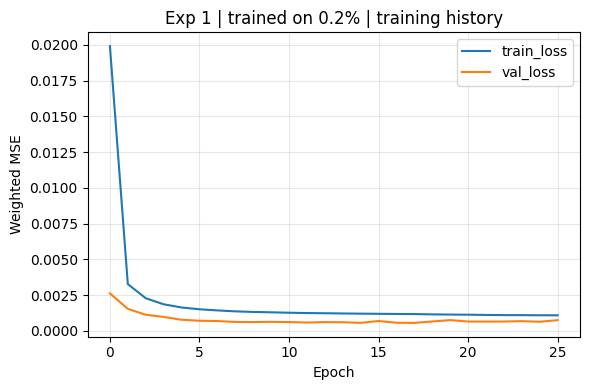


  --- Exp1_train0.2%_test0.2% [MATCHED] (rate_mult=2.724, threshold=0.005082) ---
  Precision=0.1026  Recall=0.2800  F1=0.1501  FPR=0.0049  FNR=0.7200  AUC=0.9910

Confusion matrix - Exp1_train0.2%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49655            245
Actual: Attack              72             28


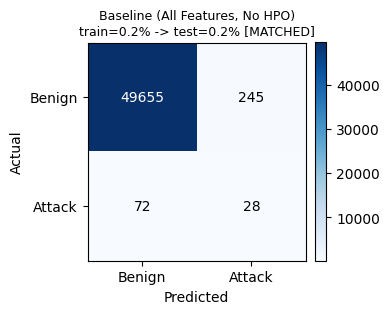


  --- Exp1_train0.2%_test1% [cross] (rate_mult=2.164, threshold=0.003460) ---
  Precision=0.3743  Recall=0.8100  F1=0.5120  FPR=0.0137  FNR=0.1900  AUC=0.9911

Confusion matrix - Exp1_train0.2%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48823            677
Actual: Attack              95            405


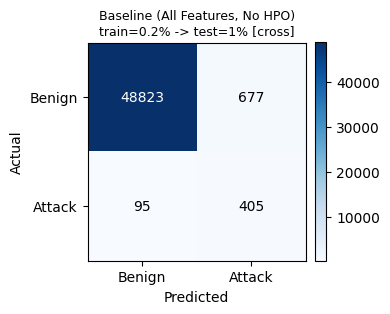


  --- Exp1_train0.2%_test5% [cross] (rate_mult=1.264, threshold=0.003150) ---
  Precision=0.7576  Recall=0.9576  F1=0.8459  FPR=0.0161  FNR=0.0424  AUC=0.9908

Confusion matrix - Exp1_train0.2%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46734            766
Actual: Attack             106           2394


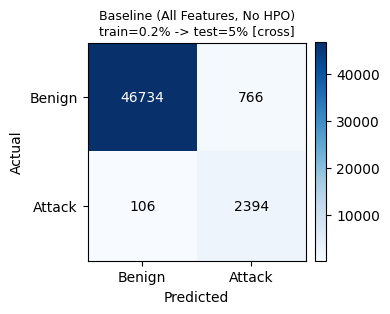


  Saved model + artifacts to: /content/ae_models_v3_cross/exp1_train0_2pct

------------------------------------------------------------------------------
  TRAINING on: 1%  (Exp 1: Baseline (All Features, No HPO))
------------------------------------------------------------------------------
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 78)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,766 (49.87 KB)

 Trainable params: 12,510 (48.87 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0195 - val_loss: 0.0029
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0017 - val_loss: 9.9346e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 9.9135e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0013 - val_loss: 8.1258e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0013 - val_loss: 8.7758e-04
Epoch 12/80
10

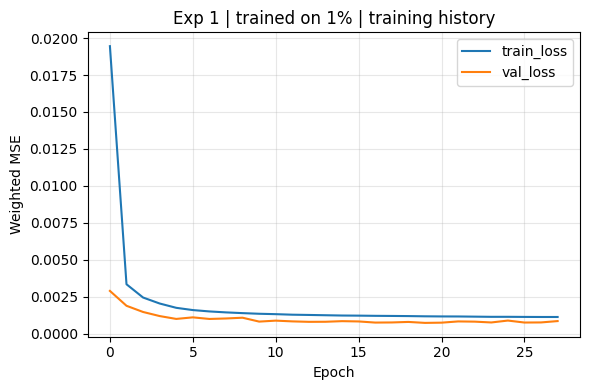


  --- Exp1_train1%_test0.2% [cross] (rate_mult=3.704, threshold=0.004430) ---
  Precision=0.1024  Recall=0.3800  F1=0.1614  FPR=0.0067  FNR=0.6200  AUC=0.9911

Confusion matrix - Exp1_train1%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49567            333
Actual: Attack              62             38


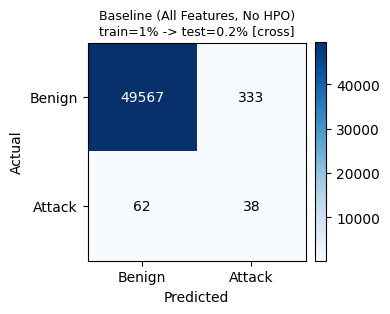


  --- Exp1_train1%_test1% [MATCHED] (rate_mult=2.004, threshold=0.003418) ---
  Precision=0.4032  Recall=0.8080  F1=0.5379  FPR=0.0121  FNR=0.1920  AUC=0.9917

Confusion matrix - Exp1_train1%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48902            598
Actual: Attack              96            404


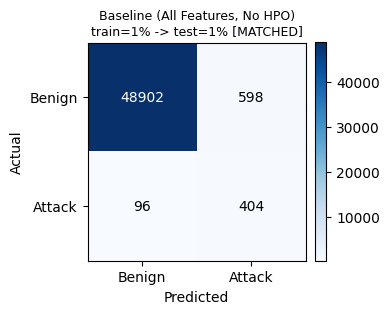


  --- Exp1_train1%_test5% [cross] (rate_mult=1.170, threshold=0.003272) ---
  Precision=0.7823  Recall=0.9156  F1=0.8437  FPR=0.0134  FNR=0.0844  AUC=0.9914

Confusion matrix - Exp1_train1%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46863            637
Actual: Attack             211           2289


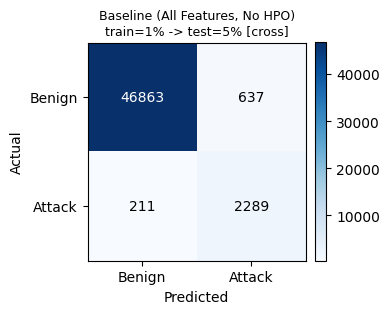


  Saved model + artifacts to: /content/ae_models_v3_cross/exp1_train1pct

------------------------------------------------------------------------------
  TRAINING on: 5%  (Exp 1: Baseline (All Features, No HPO))
------------------------------------------------------------------------------
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 78)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,766 (49.87 KB)

 Trainable params: 12,510 (48.87 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0197 - val_loss: 0.0048
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0024 - val_loss: 0.0026
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 12/80
1055/1055 ━━━━━━━━

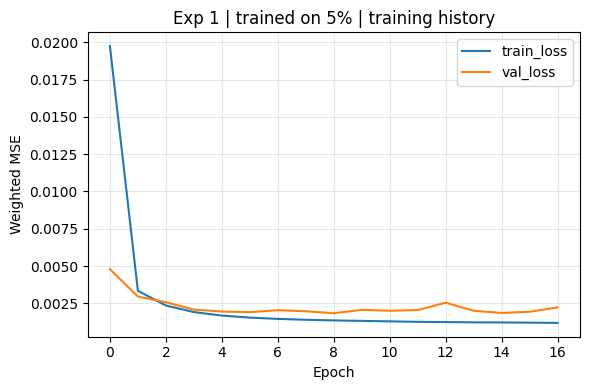


  --- Exp1_train5%_test0.2% [cross] (rate_mult=3.704, threshold=0.005577) ---
  Precision=0.0404  Recall=0.1500  F1=0.0637  FPR=0.0071  FNR=0.8500  AUC=0.9897

Confusion matrix - Exp1_train5%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49544            356
Actual: Attack              85             15


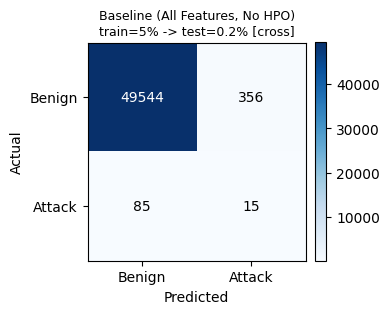


  --- Exp1_train5%_test1% [cross] (rate_mult=2.336, threshold=0.003996) ---
  Precision=0.4123  Recall=0.9640  F1=0.5776  FPR=0.0139  FNR=0.0360  AUC=0.9899

Confusion matrix - Exp1_train5%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48813            687
Actual: Attack              18            482


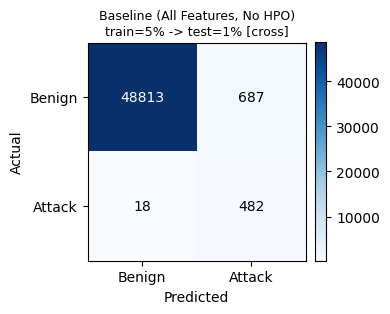


  --- Exp1_train5%_test5% [MATCHED] (rate_mult=1.264, threshold=0.003802) ---
  Precision=0.7728  Recall=0.9768  F1=0.8629  FPR=0.0151  FNR=0.0232  AUC=0.9898

Confusion matrix - Exp1_train5%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46782            718
Actual: Attack              58           2442


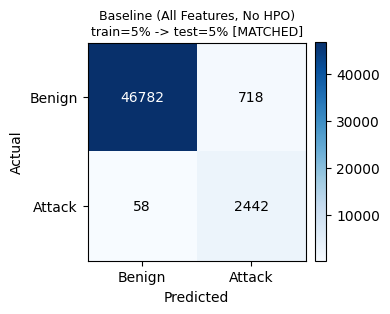


  Saved model + artifacts to: /content/ae_models_v3_cross/exp1_train5pct


,Experiment,ExperimentName,TrainSet,TestSet,Matched,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,1,"Baseline (All Features, No HPO)",0.2%,0.2%,True,False,False,78,2.724340,0.005082,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.102564,0.2800,0.150134,0.004910,0.7200,0.990972,28,245,72,49655
1,1,"Baseline (All Features, No HPO)",0.2%,1%,False,False,False,78,2.163625,0.003460,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.374307,0.8100,0.512010,0.013677,0.1900,0.991086,405,677,95,48823
2,1,"Baseline (All Features, No HPO)",0.2%,5%,False,False,False,78,1.263758,0.003150,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.757595,0.9576,0.845936,0.016126,0.0424,0.990766,2394,766,106,46734
3,1,"Baseline (All Features, No HPO)",1%,0.2%,False,False,False,78,3.704250,0.004430,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.102426,0.3800,0.161359,0.006673,0.6200,0.991141,38,333,62,49567
4,1,"Baseline (All Features, No HPO)",1%,1%,True,False,False,78,2.003652,0.003418,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.403194,0.8080,0.537949,0.012081,0.1920,0.991676,404,598,96,48902
5,1,"Baseline (All Features, No HPO)",1%,5%,False,False,False,78,1.170319,0.003272,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.782297,0.9156,0.843715,0.013411,0.0844,0.991426,2289,637,211,46863
6,1,"Baseline (All Features, No HPO)",5%,0.2%,False,False,False,78,3.704250,0.005577,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.040431,0.1500,0.063694,0.007134,0.8500,0.989652,15,356,85,49544
7,1,"Baseline (All Features, No HPO)",5%,1%,False,False,False,78,2.336371,0.003996,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.412318,0.9640,0.577591,0.013879,0.0360,0.989943,482,687,18,48813
8,1,"Baseline (All Features, No HPO)",5%,5%,True,False,False,78,1.263758,0.003802,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.772785,0.9768,0.862898,0.015116,0.0232,0.989799,2442,718,58,46782



EXPERIMENT 2: Feature-Selected (No HPO)

------------------------------------------------------------------------------
  TRAINING on: 0.2%  (Exp 2: Feature-Selected (No HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,219 (28.20 KB)

 Trainable params: 6,963 (27.20 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0125 - val_loss: 0.0022
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0033 - val_loss: 0.0014
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0020 - val_loss: 9.0381e-04
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0018 - val_loss: 7.7891e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0016 - val_loss: 6.8977e-04
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 6.7902e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 7.0553e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0014 - val_loss: 6.3213e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0014 - val_loss: 5.7745e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0014 - val_loss: 5.7965e-0

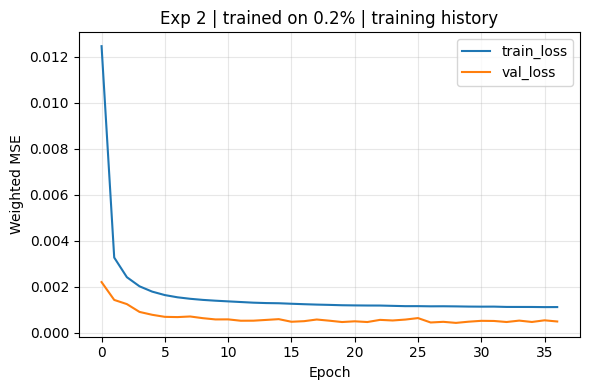


  --- Exp2_train0.2%_test0.2% [MATCHED] (rate_mult=1.718, threshold=0.003132) ---
  Precision=0.2616  Recall=0.4500  F1=0.3309  FPR=0.0025  FNR=0.5500  AUC=0.9964

Confusion matrix - Exp2_train0.2%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49773            127
Actual: Attack              55             45


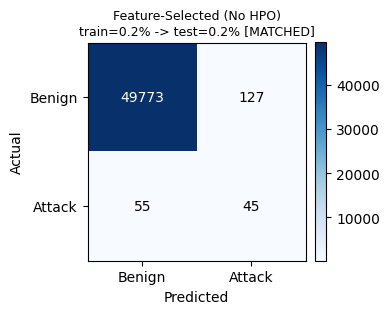


  --- Exp2_train0.2%_test1% [cross] (rate_mult=1.591, threshold=0.002434) ---
  Precision=0.6118  Recall=0.9740  F1=0.7515  FPR=0.0062  FNR=0.0260  AUC=0.9965

Confusion matrix - Exp2_train0.2%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49191            309
Actual: Attack              13            487


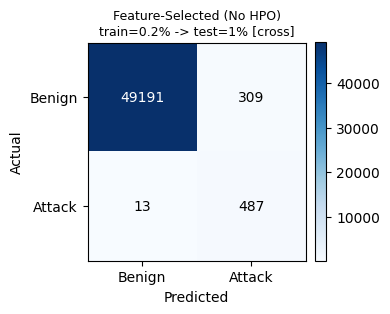


  --- Exp2_train0.2%_test5% [cross] (rate_mult=1.084, threshold=0.002434) ---
  Precision=0.8915  Recall=0.9664  F1=0.9274  FPR=0.0062  FNR=0.0336  AUC=0.9965

Confusion matrix - Exp2_train0.2%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47206            294
Actual: Attack              84           2416


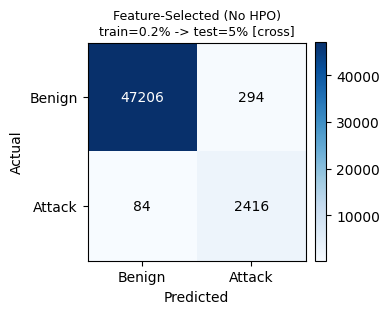


  Saved model + artifacts to: /content/ae_models_v3_cross/exp2_train0_2pct

------------------------------------------------------------------------------
  TRAINING on: 1%  (Exp 2: Feature-Selected (No HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,219 (28.20 KB)

 Trainable params: 6,963 (27.20 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0126 - val_loss: 0.0026
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0015 - val_loss: 9.6321e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0015 - val_loss: 9.6245e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0014 - val_loss: 8.8721e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0014 - val_loss: 8.7579e-04
Epoch 12/80
1

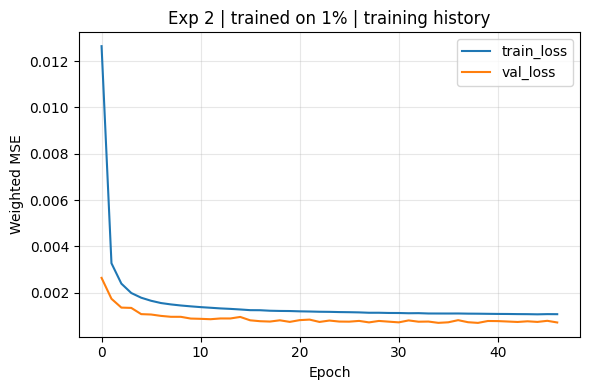


  --- Exp2_train1%_test0.2% [cross] (rate_mult=1.264, threshold=0.004899) ---
  Precision=0.4803  Recall=0.6100  F1=0.5374  FPR=0.0013  FNR=0.3900  AUC=0.9819

Confusion matrix - Exp2_train1%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49834             66
Actual: Attack              39             61


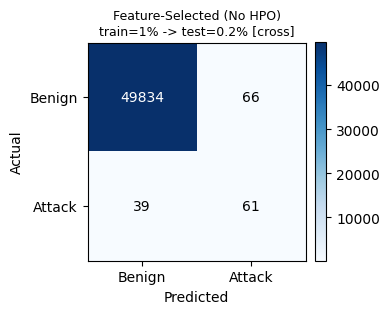


  --- Exp2_train1%_test1% [MATCHED] (rate_mult=0.797, threshold=0.004824) ---
  Precision=0.8296  Recall=0.6620  F1=0.7364  FPR=0.0014  FNR=0.3380  AUC=0.9815

Confusion matrix - Exp2_train1%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49432             68
Actual: Attack             169            331


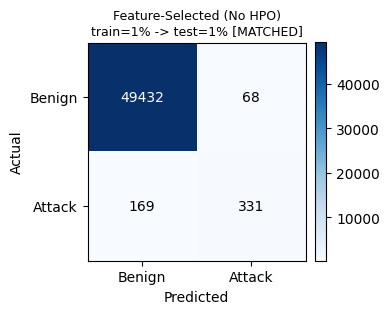


  --- Exp2_train1%_test5% [cross] (rate_mult=0.684, threshold=0.004810) ---
  Precision=0.9602  Recall=0.6564  F1=0.7798  FPR=0.0014  FNR=0.3436  AUC=0.9812

Confusion matrix - Exp2_train1%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47432             68
Actual: Attack             859           1641


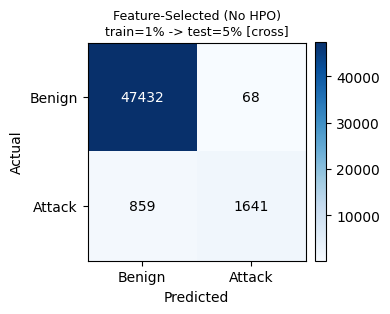


  Saved model + artifacts to: /content/ae_models_v3_cross/exp2_train1pct

------------------------------------------------------------------------------
  TRAINING on: 5%  (Exp 2: Feature-Selected (No HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,219 (28.20 KB)

 Trainable params: 6,963 (27.20 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0127 - val_loss: 0.0041
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0020 - val_loss: 0.0026
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0018 - val_loss: 0.0024
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0013 - val_loss: 0.0023
Epoch 12/80
1055/1055 ━━━━━━

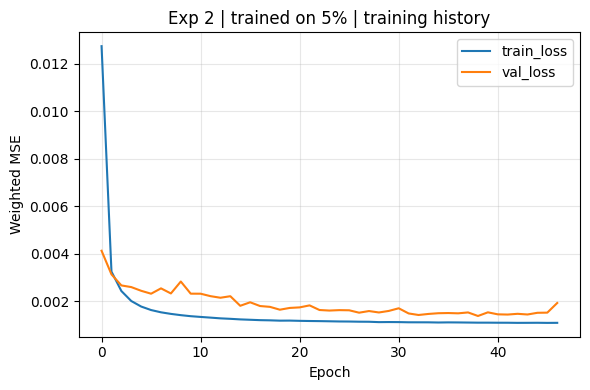


  --- Exp2_train5%_test0.2% [cross] (rate_mult=1.718, threshold=0.003785) ---
  Precision=0.4012  Recall=0.6900  F1=0.5074  FPR=0.0021  FNR=0.3100  AUC=0.9854

Confusion matrix - Exp2_train5%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49797            103
Actual: Attack              31             69


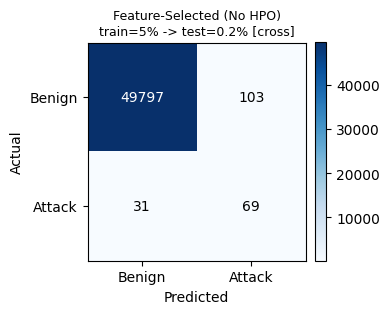


  --- Exp2_train5%_test1% [cross] (rate_mult=0.797, threshold=0.004052) ---
  Precision=0.7870  Recall=0.6280  F1=0.6986  FPR=0.0017  FNR=0.3720  AUC=0.9857

Confusion matrix - Exp2_train5%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49415             85
Actual: Attack             186            314


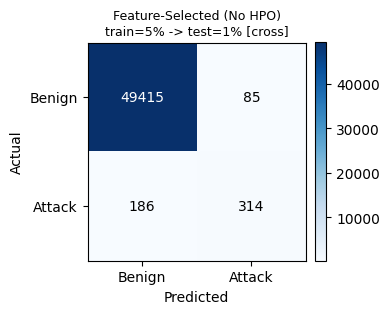


  --- Exp2_train5%_test5% [MATCHED] (rate_mult=0.684, threshold=0.004029) ---
  Precision=0.9514  Recall=0.6504  F1=0.7726  FPR=0.0017  FNR=0.3496  AUC=0.9854

Confusion matrix - Exp2_train5%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47417             83
Actual: Attack             874           1626


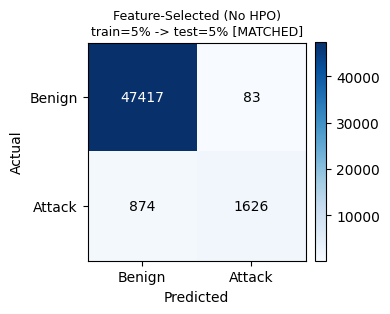


  Saved model + artifacts to: /content/ae_models_v3_cross/exp2_train5pct


,Experiment,ExperimentName,TrainSet,TestSet,Matched,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,2,Feature-Selected (No HPO),0.2%,0.2%,True,True,False,35,1.718315,0.003132,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.261628,0.4500,0.330882,0.002545,0.5500,0.996431,45,127,55,49773
1,2,Feature-Selected (No HPO),0.2%,1%,False,True,False,35,1.591267,0.002434,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.611809,0.9740,0.751543,0.006242,0.0260,0.996495,487,309,13,49191
2,2,Feature-Selected (No HPO),0.2%,5%,False,True,False,35,1.083788,0.002434,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.891513,0.9664,0.927447,0.006189,0.0336,0.996483,2416,294,84,47206
3,2,Feature-Selected (No HPO),1%,0.2%,False,True,False,35,1.263758,0.004899,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.480315,0.6100,0.537445,0.001323,0.3900,0.981944,61,66,39,49834
4,2,Feature-Selected (No HPO),1%,1%,True,True,False,35,0.797086,0.004824,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.829574,0.6620,0.736374,0.001374,0.3380,0.981546,331,68,169,49432
5,2,Feature-Selected (No HPO),1%,5%,False,True,False,35,0.683575,0.004810,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.960211,0.6564,0.779758,0.001432,0.3436,0.981250,1641,68,859,47432
6,2,Feature-Selected (No HPO),5%,0.2%,False,True,False,35,1.718315,0.003785,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.401163,0.6900,0.507353,0.002064,0.3100,0.985388,69,103,31,49797
7,2,Feature-Selected (No HPO),5%,1%,False,True,False,35,0.797086,0.004052,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.786967,0.6280,0.698554,0.001717,0.3720,0.985689,314,85,186,49415
8,2,Feature-Selected (No HPO),5%,5%,True,True,False,35,0.683575,0.004029,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.951434,0.6504,0.772630,0.001747,0.3496,0.985411,1626,83,874,47417



EXPERIMENT 3: Optimized (All Features, With HPO)

------------------------------------------------------------------------------
  TRAINING on: 0.2%  (Exp 3: Optimized (All Features, With HPO))
------------------------------------------------------------------------------
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 78)


  [Optuna:exp3_train0.2%] best composite score=-0.0500
  [Optuna:exp3_train0.2%] best params={'encoding_dim': 8, 'hidden_dim': 192, 'n_hidden_layers': 1, 'learning_rate': 3.1261029103110585e-05, 'dropout': 0.1216968971838151, 'l2_reg': 4.205156450913872e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │         1,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │        15,054 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,030 (136.84 KB)

 Trainable params: 34,262 (133.84 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.1345 - val_loss: 0.0886
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0753 - val_loss: 0.0485
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0410 - val_loss: 0.0244
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0240 - val_loss: 0.0150
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0162 - val_loss: 0.0102
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0123 - val_loss: 0.0076
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0097 - val_loss: 0.0063
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0082 - val_loss: 0.0054
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0071 - val_loss: 0.0047
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0063 - val_loss: 0.0042
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0056 - val_loss: 0.0038
Epoch 12

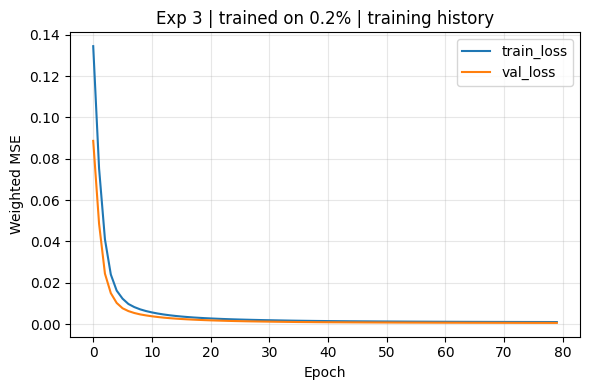


  --- Exp3_train0.2%_test0.2% [MATCHED] (rate_mult=0.200, threshold=0.018514) ---
  Precision=0.0000  Recall=0.0000  F1=0.0000  FPR=0.0004  FNR=1.0000  AUC=0.9807

Confusion matrix - Exp3_train0.2%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49880             20
Actual: Attack             100              0


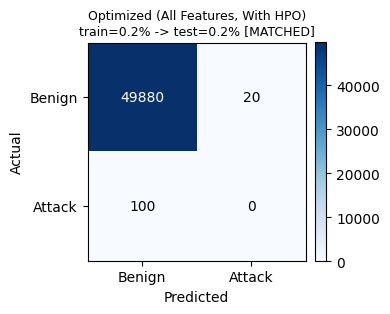


  --- Exp3_train0.2%_test1% [cross] (rate_mult=2.523, threshold=0.003333) ---
  Precision=0.2496  Recall=0.6300  F1=0.3575  FPR=0.0191  FNR=0.3700  AUC=0.9810

Confusion matrix - Exp3_train0.2%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48553            947
Actual: Attack             185            315


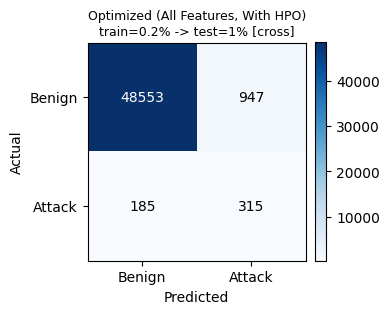


  --- Exp3_train0.2%_test5% [cross] (rate_mult=1.591, threshold=0.002323) ---
  Precision=0.5994  Recall=0.9540  F1=0.7362  FPR=0.0336  FNR=0.0460  AUC=0.9808

Confusion matrix - Exp3_train0.2%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           45906           1594
Actual: Attack             115           2385


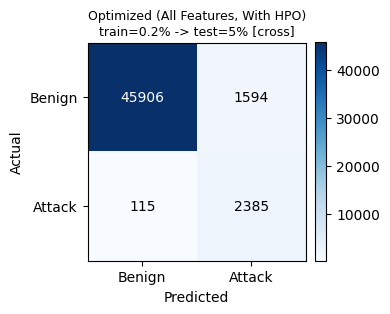


  Saved model + artifacts to: /content/ae_models_v3_cross/exp3_train0_2pct

------------------------------------------------------------------------------
  TRAINING on: 1%  (Exp 3: Optimized (All Features, With HPO))
------------------------------------------------------------------------------
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 78)
  [Optuna:exp3_train1%] best composite score=0.3140
  [Optuna:exp3_train1%] best params={'encoding_dim': 24, 'hidden_dim': 128, 'n_hidden_layers': 1, 'learning_rate': 0.0006422315437929134, 'dropout': 0.04959758918165445, 'l2_reg': 4.6388810185480496e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 24)             │         3,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,494 (107.40 KB)

 Trainable params: 26,982 (105.40 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.0221 - val_loss: 0.0048
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0015 - val_loss: 9.6173e-04
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0011 - val_loss: 7.9453e-04
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 9.4369e-04 - val_loss: 7.4740e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 8.4671e-04 - val_loss: 7.5772e-04
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7.7770e-04 - val_loss: 6.1484e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7.2507e-04 - val_loss: 6.0128e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6.8466e-04 - val_loss: 6.0280e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6.5370e-04 - val_loss: 6.2243e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11m

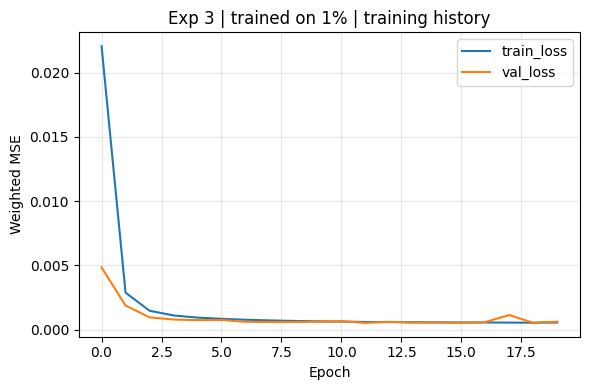


  --- Exp3_train1%_test0.2% [cross] (rate_mult=2.004, threshold=0.003212) ---
  Precision=0.2687  Recall=0.5400  F1=0.3588  FPR=0.0029  FNR=0.4600  AUC=0.9965

Confusion matrix - Exp3_train1%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49753            147
Actual: Attack              46             54


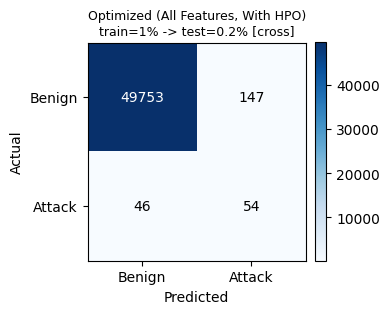


  --- Exp3_train1%_test1% [MATCHED] (rate_mult=1.474, threshold=0.002457) ---
  Precision=0.5848  Recall=0.8620  F1=0.6968  FPR=0.0062  FNR=0.1380  AUC=0.9967

Confusion matrix - Exp3_train1%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49194            306
Actual: Attack              69            431


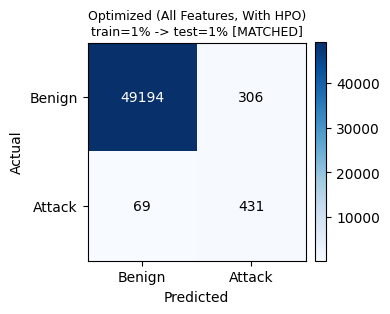


  --- Exp3_train1%_test5% [cross] (rate_mult=1.084, threshold=0.002451) ---
  Precision=0.8911  Recall=0.9660  F1=0.9271  FPR=0.0062  FNR=0.0340  AUC=0.9967

Confusion matrix - Exp3_train1%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47205            295
Actual: Attack              85           2415


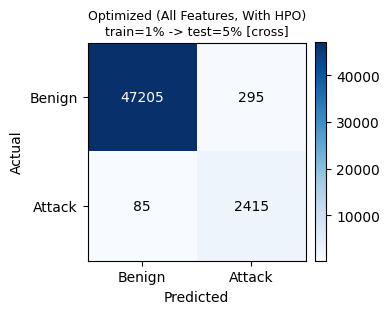


  Saved model + artifacts to: /content/ae_models_v3_cross/exp3_train1pct

------------------------------------------------------------------------------
  TRAINING on: 5%  (Exp 3: Optimized (All Features, With HPO))
------------------------------------------------------------------------------
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 78)
  [Optuna:exp3_train5%] best composite score=0.2172
  [Optuna:exp3_train5%] best params={'encoding_dim': 8, 'hidden_dim': 192, 'n_hidden_layers': 1, 'learning_rate': 3.1261029103110585e-05, 'dropout': 0.1216968971838151, 'l2_reg': 4.205156450913872e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │         1,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │        15,054 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,030 (136.84 KB)

 Trainable params: 34,262 (133.84 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.1312 - val_loss: 0.1003
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0718 - val_loss: 0.0571
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0402 - val_loss: 0.0329
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0249 - val_loss: 0.0241
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0180 - val_loss: 0.0186
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0142 - val_loss: 0.0122
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0115 - val_loss: 0.0097
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0092 - val_loss: 0.0082
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0079 - val_loss: 0.0074
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0070 - val_loss: 0.0067
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0063 - val_loss: 0.0063
Epoch 12

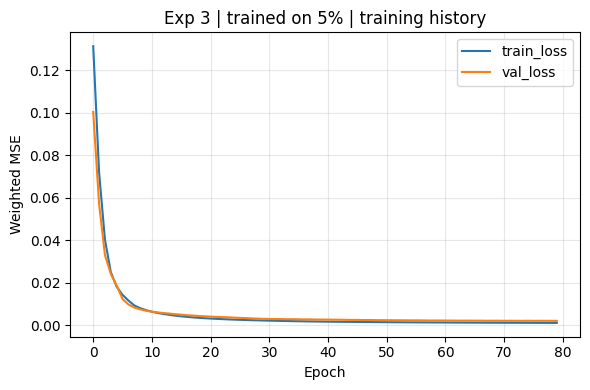


  --- Exp3_train5%_test0.2% [cross] (rate_mult=4.000, threshold=0.005603) ---
  Precision=0.0525  Recall=0.2100  F1=0.0840  FPR=0.0076  FNR=0.7900  AUC=0.9891

Confusion matrix - Exp3_train5%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49521            379
Actual: Attack              79             21


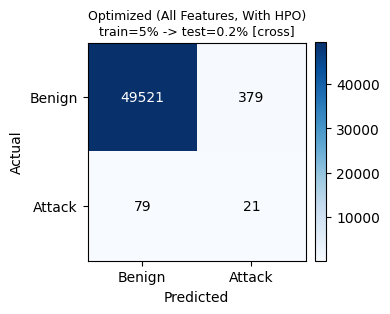


  --- Exp3_train5%_test1% [cross] (rate_mult=2.942, threshold=0.003314) ---
  Precision=0.3392  Recall=0.9980  F1=0.5063  FPR=0.0196  FNR=0.0020  AUC=0.9895

Confusion matrix - Exp3_train5%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48528            972
Actual: Attack               1            499


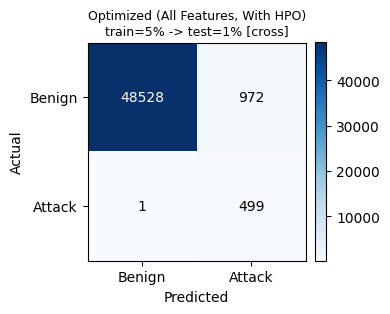


  --- Exp3_train5%_test5% [MATCHED] (rate_mult=1.365, threshold=0.003369) ---
  Precision=0.7304  Recall=0.9968  F1=0.8430  FPR=0.0194  FNR=0.0032  AUC=0.9894

Confusion matrix - Exp3_train5%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46580            920
Actual: Attack               8           2492


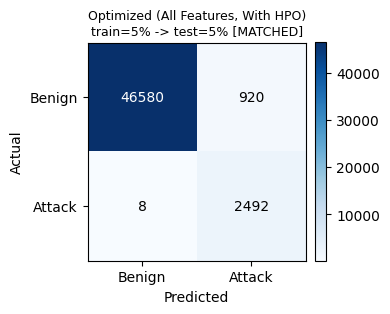


  Saved model + artifacts to: /content/ae_models_v3_cross/exp3_train5pct


,Experiment,ExperimentName,TrainSet,TestSet,Matched,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,3,"Optimized (All Features, With HPO)",0.2%,0.2%,True,False,True,78,0.200000,0.018514,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.000000,0.0000,0.000000,0.000401,1.0000,0.980651,0,20,100,49880
1,3,"Optimized (All Features, With HPO)",0.2%,1%,False,False,True,78,2.522909,0.003333,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.249604,0.6300,0.357548,0.019131,0.3700,0.981040,315,947,185,48553
2,3,"Optimized (All Features, With HPO)",0.2%,5%,False,False,True,78,1.591267,0.002323,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.599397,0.9540,0.736225,0.033558,0.0460,0.980804,2385,1594,115,45906
3,3,"Optimized (All Features, With HPO)",1%,0.2%,False,False,True,78,2.003652,0.003212,"{""encoding_dim"": 24, ""hidden_dim"": 128, ""n_hid...",0.268657,0.5400,0.358804,0.002946,0.4600,0.996485,54,147,46,49753
4,3,"Optimized (All Features, With HPO)",1%,1%,True,False,True,78,1.473613,0.002457,"{""encoding_dim"": 24, ""hidden_dim"": 128, ""n_hid...",0.584803,0.8620,0.696847,0.006182,0.1380,0.996692,431,306,69,49194
5,3,"Optimized (All Features, With HPO)",1%,5%,False,False,True,78,1.083788,0.002451,"{""encoding_dim"": 24, ""hidden_dim"": 128, ""n_hid...",0.891144,0.9660,0.927063,0.006211,0.0340,0.996670,2415,295,85,47205
6,3,"Optimized (All Features, With HPO)",5%,0.2%,False,False,True,78,4.000000,0.005603,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.052500,0.2100,0.084000,0.007595,0.7900,0.989149,21,379,79,49521
7,3,"Optimized (All Features, With HPO)",5%,1%,False,False,True,78,2.941853,0.003314,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.339225,0.9980,0.506342,0.019636,0.0020,0.989470,499,972,1,48528
8,3,"Optimized (All Features, With HPO)",5%,5%,True,False,True,78,1.364657,0.003369,"{""encoding_dim"": 8, ""hidden_dim"": 192, ""n_hidd...",0.730363,0.9968,0.843031,0.019368,0.0032,0.989402,2492,920,8,46580



EXPERIMENT 4: Optimized Feature-Selected (With HPO)

------------------------------------------------------------------------------
  TRAINING on: 0.2%  (Exp 4: Optimized Feature-Selected (With HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  [Optuna:exp4_train0.2%] best composite score=0.4560
  [Optuna:exp4_train0.2%] best params={'encoding_dim': 64, 'hidden_dim': 128, 'n_hidden_layers': 1, 'learning_rate': 0.0003875196992166184, 'dropout': 0.03040271087810922, 'l2_reg': 8.454925780668509e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,723 (104.39 KB)

 Trainable params: 26,211 (102.39 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0236 - val_loss: 0.0088
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0055 - val_loss: 0.0035
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0014 - val_loss: 7.9093e-04
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0011 - val_loss: 6.3661e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 9.9856e-04 - val_loss: 5.9803e-04
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 8.9759e-04 - val_loss: 5.3647e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 8.2415e-04 - val_loss: 5.6848e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 7.6653e-04 - val_loss: 5.0345e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7.2033e-04 - val_loss: 5.2622e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/st

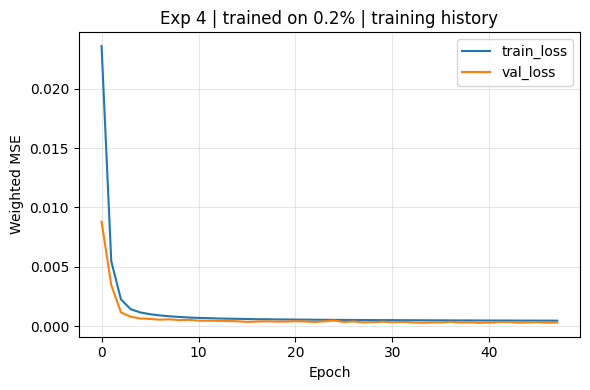


  --- Exp4_train0.2%_test0.2% [MATCHED] (rate_mult=2.942, threshold=0.000953) ---
  Precision=0.2102  Recall=0.6200  F1=0.3139  FPR=0.0047  FNR=0.3800  AUC=0.9787

Confusion matrix - Exp4_train0.2%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49667            233
Actual: Attack              38             62


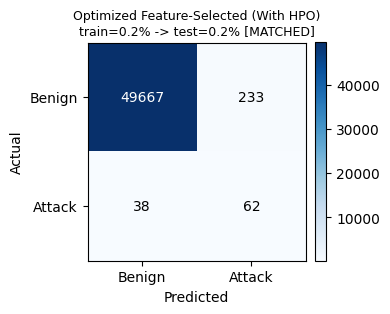


  --- Exp4_train0.2%_test1% [cross] (rate_mult=0.929, threshold=0.001053) ---
  Precision=0.5935  Recall=0.5520  F1=0.5720  FPR=0.0038  FNR=0.4480  AUC=0.9762

Confusion matrix - Exp4_train0.2%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49311            189
Actual: Attack             224            276


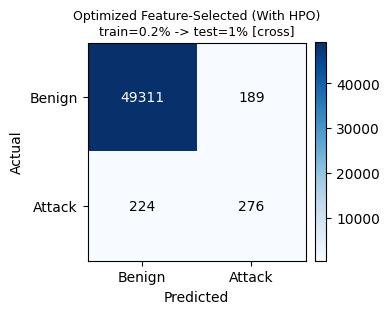


  --- Exp4_train0.2%_test5% [cross] (rate_mult=0.797, threshold=0.000742) ---
  Precision=0.8118  Recall=0.6472  F1=0.7202  FPR=0.0079  FNR=0.3528  AUC=0.9756

Confusion matrix - Exp4_train0.2%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47125            375
Actual: Attack             882           1618


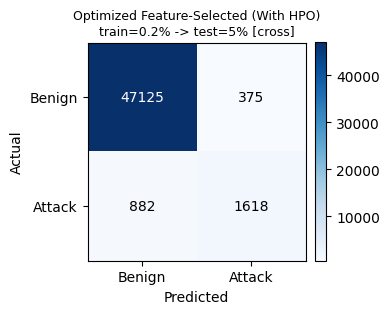


  Saved model + artifacts to: /content/ae_models_v3_cross/exp4_train0_2pct

------------------------------------------------------------------------------
  TRAINING on: 1%  (Exp 4: Optimized Feature-Selected (With HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  [Optuna:exp4_train1%] best composite score=0.4263
  [Optuna:exp4_train1%] best params={'encoding_dim': 64, 'hidden_dim': 128, 'n_hidden_layers': 1, 'learning_rate': 0.0008597724229150342, 'dropout': 0.2476044638448256, 'l2_reg': 4.628808943824091e-06}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,723 (104.39 KB)

 Trainable params: 26,211 (102.39 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0115 - val_loss: 0.0020
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0031 - val_loss: 0.0015
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0019 - val_loss: 9.5750e-04
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0017 - val_loss: 8.0075e-04
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0016 - val_loss: 7.4286e-04
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0015 - val_loss: 7.5078e-04
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0014 - val_loss: 7.1882e-04
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0014 - val_loss: 6.7168e-04
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0014 - val_loss: 6.7399e-04
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0013 -

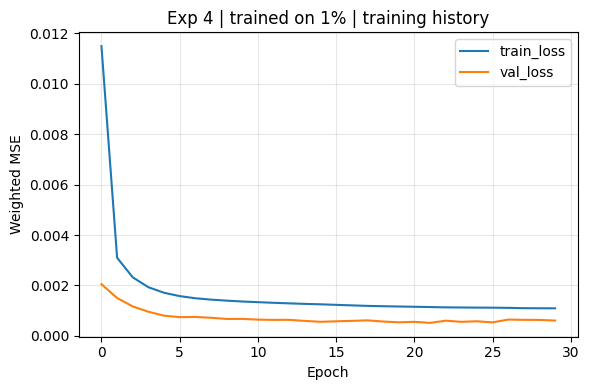


  --- Exp4_train1%_test0.2% [cross] (rate_mult=1.856, threshold=0.002542) ---
  Precision=0.3441  Recall=0.6400  F1=0.4476  FPR=0.0024  FNR=0.3600  AUC=0.9932

Confusion matrix - Exp4_train1%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49778            122
Actual: Attack              36             64


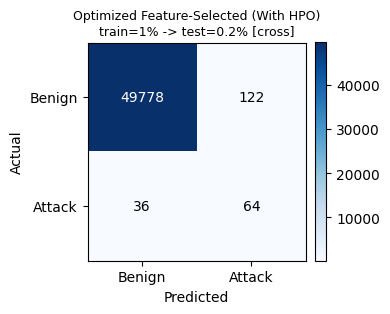


  --- Exp4_train1%_test1% [MATCHED] (rate_mult=0.861, threshold=0.002550) ---
  Precision=0.7239  Recall=0.6240  F1=0.6702  FPR=0.0024  FNR=0.3760  AUC=0.9928

Confusion matrix - Exp4_train1%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49381            119
Actual: Attack             188            312


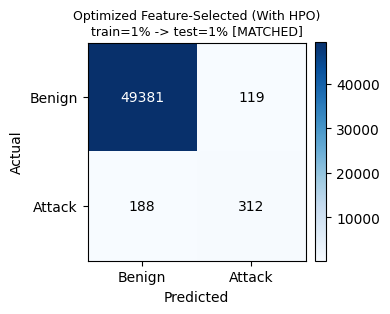


  --- Exp4_train1%_test5% [cross] (rate_mult=1.365, threshold=0.001019) ---
  Precision=0.6852  Recall=0.9352  F1=0.7909  FPR=0.0226  FNR=0.0648  AUC=0.9926

Confusion matrix - Exp4_train1%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46426           1074
Actual: Attack             162           2338


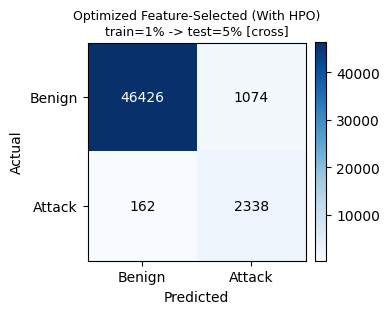


  Saved model + artifacts to: /content/ae_models_v3_cross/exp4_train1pct

------------------------------------------------------------------------------
  TRAINING on: 5%  (Exp 4: Optimized Feature-Selected (With HPO))
------------------------------------------------------------------------------
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (300000, 35)
  [Optuna:exp4_train5%] best composite score=0.5367
  [Optuna:exp4_train5%] best params={'encoding_dim': 32, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.002516617476541867, 'dropout': 0.3802813482907235, 'l2_reg': 2.750656545857466e-07}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,283 (36.26 KB)

 Trainable params: 9,027 (35.26 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0116 - val_loss: 0.0038
Epoch 2/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0047 - val_loss: 0.0038
Epoch 3/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 4/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 5/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 6/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 7/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0035 - val_loss: 0.0033
Epoch 8/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 9/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 10/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 11/80
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 12/80
1055/1055 ━━━━━━━

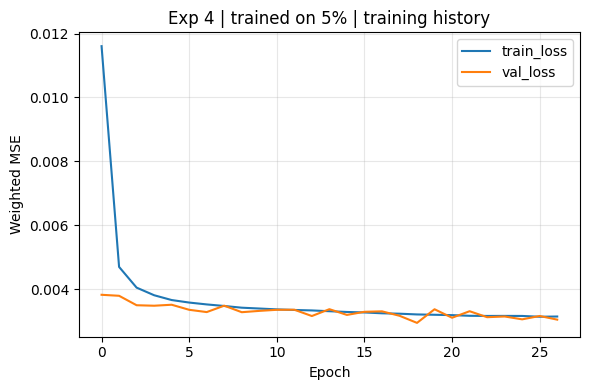


  --- Exp4_train5%_test0.2% [cross] (rate_mult=2.724, threshold=0.008199) ---
  Precision=0.0696  Recall=0.1900  F1=0.1019  FPR=0.0051  FNR=0.8100  AUC=0.9839

Confusion matrix - Exp4_train5%_test0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49646            254
Actual: Attack              81             19


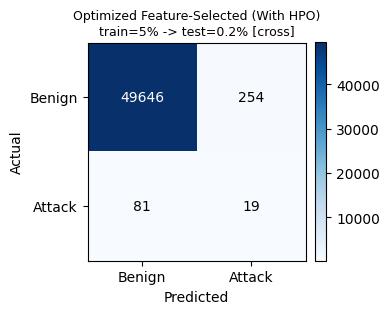


  --- Exp4_train5%_test1% [cross] (rate_mult=3.177, threshold=0.004487) ---
  Precision=0.2675  Recall=0.8500  F1=0.4069  FPR=0.0235  FNR=0.1500  AUC=0.9834

Confusion matrix - Exp4_train5%_test1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48336           1164
Actual: Attack              75            425


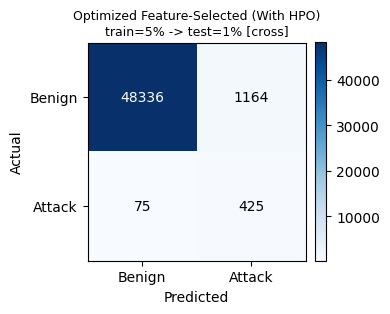


  --- Exp4_train5%_test5% [MATCHED] (rate_mult=1.591, threshold=0.003632) ---
  Precision=0.6105  Recall=0.9716  F1=0.7498  FPR=0.0326  FNR=0.0284  AUC=0.9832

Confusion matrix - Exp4_train5%_test5%
                  Pred: Benign   Pred: Attack
Actual: Benign           45950           1550
Actual: Attack              71           2429


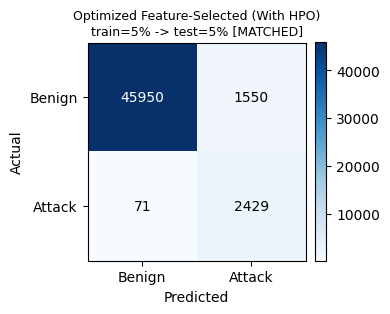


  Saved model + artifacts to: /content/ae_models_v3_cross/exp4_train5pct


,Experiment,ExperimentName,TrainSet,TestSet,Matched,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,4,Optimized Feature-Selected (With HPO),0.2%,0.2%,True,True,True,35,2.941853,0.000953,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.210169,0.6200,0.313924,0.004669,0.3800,0.978737,62,233,38,49667
1,4,Optimized Feature-Selected (With HPO),0.2%,1%,False,True,True,35,0.929448,0.001053,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.593548,0.5520,0.572021,0.003818,0.4480,0.976176,276,189,224,49311
2,4,Optimized Feature-Selected (With HPO),0.2%,5%,False,True,True,35,0.797086,0.000742,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.811841,0.6472,0.720231,0.007895,0.3528,0.975583,1618,375,882,47125
3,4,Optimized Feature-Selected (With HPO),1%,0.2%,False,True,True,35,1.855507,0.002542,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.344086,0.6400,0.447552,0.002445,0.3600,0.993152,64,122,36,49778
4,4,Optimized Feature-Selected (With HPO),1%,1%,True,True,True,35,0.860726,0.002550,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.723898,0.6240,0.670247,0.002404,0.3760,0.992768,312,119,188,49381
5,4,Optimized Feature-Selected (With HPO),1%,5%,False,True,True,35,1.364657,0.001019,"{""encoding_dim"": 64, ""hidden_dim"": 128, ""n_hid...",0.685229,0.9352,0.790934,0.022611,0.0648,0.992603,2338,1074,162,46426
6,4,Optimized Feature-Selected (With HPO),5%,0.2%,False,True,True,35,2.724340,0.008199,"{""encoding_dim"": 32, ""hidden_dim"": 64, ""n_hidd...",0.069597,0.1900,0.101877,0.005090,0.8100,0.983859,19,254,81,49646
7,4,Optimized Feature-Selected (With HPO),5%,1%,False,True,True,35,3.176733,0.004487,"{""encoding_dim"": 32, ""hidden_dim"": 64, ""n_hidd...",0.267464,0.8500,0.406893,0.023515,0.1500,0.983399,425,1164,75,48336
8,4,Optimized Feature-Selected (With HPO),5%,5%,True,True,True,35,1.591267,0.003632,"{""encoding_dim"": 32, ""hidden_dim"": 64, ""n_hidd...",0.610455,0.9716,0.749807,0.032632,0.0284,0.983153,2429,1550,71,45950


,Experiment,ExperimentName,TrainSet,TestSet,Matched,NumFeatures,Precision,Recall,F1,FPR,FNR,AUC
0,1,"Baseline (All Features, No HPO)",0.2%,0.2%,True,78,0.102564,0.2800,0.150134,0.004910,0.7200,0.990972
1,1,"Baseline (All Features, No HPO)",0.2%,1%,False,78,0.374307,0.8100,0.512010,0.013677,0.1900,0.991086
2,1,"Baseline (All Features, No HPO)",0.2%,5%,False,78,0.757595,0.9576,0.845936,0.016126,0.0424,0.990766
3,1,"Baseline (All Features, No HPO)",1%,0.2%,False,78,0.102426,0.3800,0.161359,0.006673,0.6200,0.991141
4,1,"Baseline (All Features, No HPO)",1%,1%,True,78,0.403194,0.8080,0.537949,0.012081,0.1920,0.991676
5,1,"Baseline (All Features, No HPO)",1%,5%,False,78,0.782297,0.9156,0.843715,0.013411,0.0844,0.991426
6,1,"Baseline (All Features, No HPO)",5%,0.2%,False,78,0.040431,0.1500,0.063694,0.007134,0.8500,0.989652
7,1,"Baseline (All Features, No HPO)",5%,1%,False,78,0.412318,0.9640,0.577591,0.013879,0.0360,0.989943
8,1,"Baseline (All Features, No HPO)",5%,5%,True,78,0.772785,0.9768,0.862898,0.015116,0.0232,0.989799
9,2,Feature-Selected (No HPO),0.2%,0.2%,True,35,0.261628,0.4500,0.330882,0.002545,0.5500,0.996431


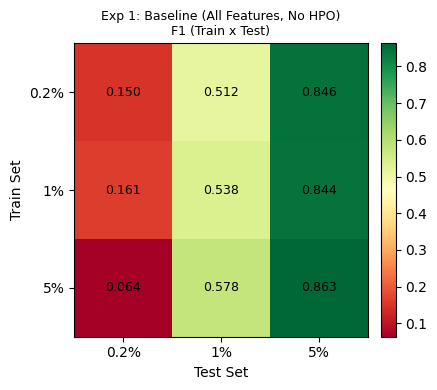

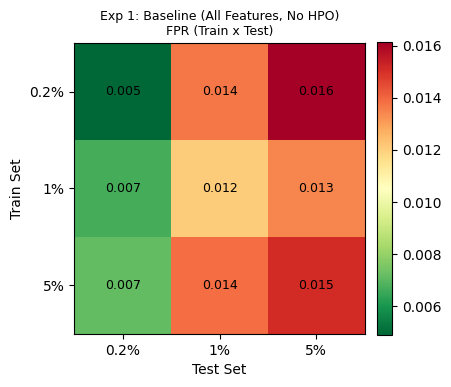

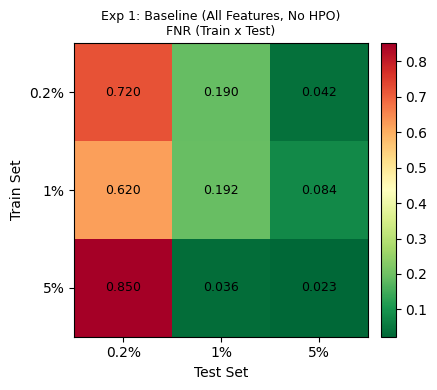

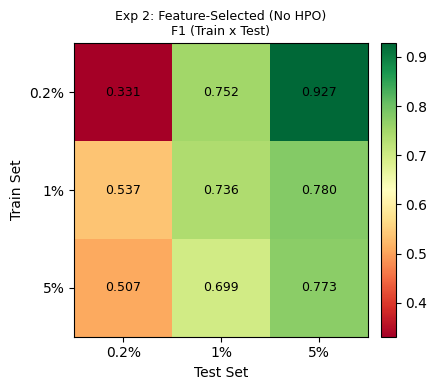

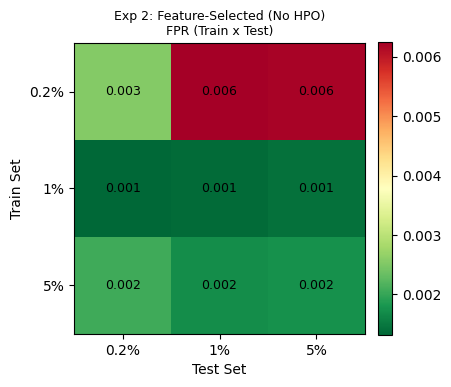

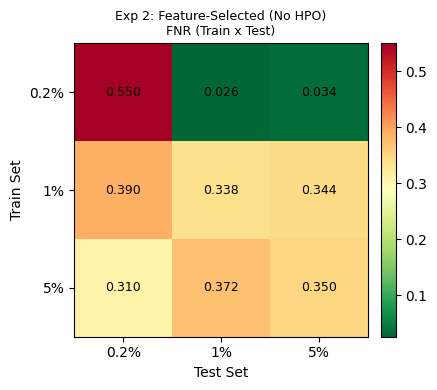

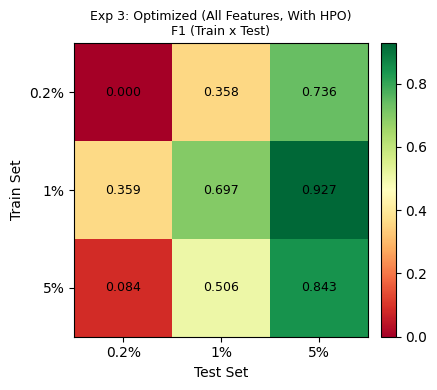

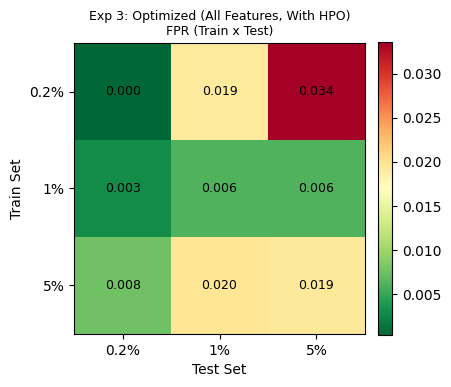

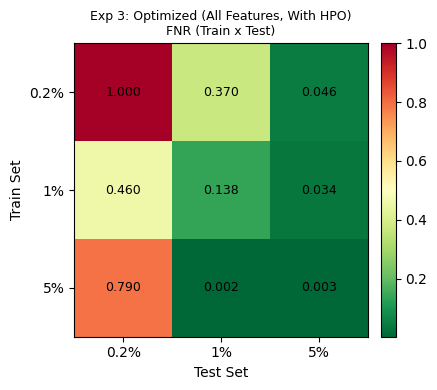

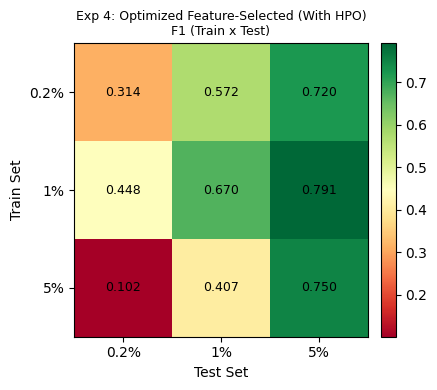

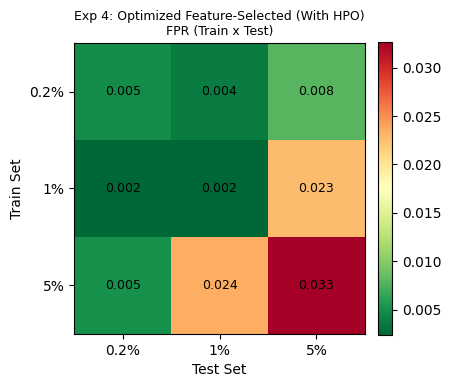

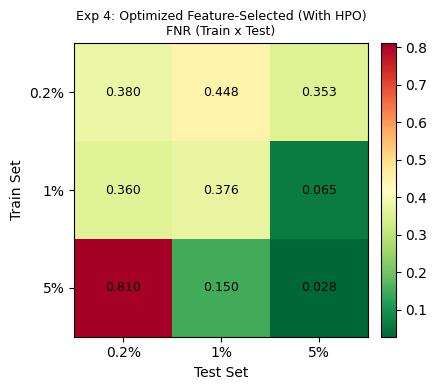


Best overall configuration (highest F1):


,Experiment,ExperimentName,TrainSet,TestSet,Matched,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
11,2,Feature-Selected (No HPO),0.2%,5%,False,True,False,35,1.083788,0.002434,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.891513,0.9664,0.927447,0.006189,0.0336,0.996483,2416,294,84,47206


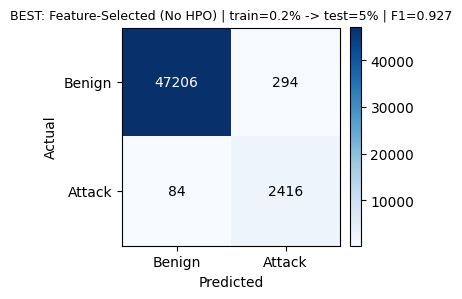


OBSERVATIONS

-- Matched (train==test) vs cross-domain average F1 --
Matched
False    0.550662
True     0.555394
Name: F1, dtype: float64

-- Best TrainSet->TestSet combo per experiment --
  Exp 1: train=5% -> test=5% F1=0.8629 FPR=0.0151 FNR=0.0232
  Exp 2: train=0.2% -> test=5% F1=0.9274 FPR=0.0062 FNR=0.0336
  Exp 3: train=1% -> test=5% F1=0.9271 FPR=0.0062 FNR=0.0340
  Exp 4: train=1% -> test=5% F1=0.7909 FPR=0.0226 FNR=0.0648

-- Effect of feature selection (avg F1) --
SelectedFeatures
False    0.503619
True     0.600860
Name: F1, dtype: float64

-- Effect of HPO (avg F1) --
HPO
False    0.588737
True     0.515742
Name: F1, dtype: float64

-- Generalization gap: matched F1 minus average cross-domain F1 (per experiment) --


,Experiment,Matched_F1,Cross_F1,Gap
0,1,0.516994,0.500718,0.016276
1,2,0.613295,0.700350,-0.087055
2,3,0.513293,0.494997,0.018296
3,4,0.577993,0.506585,0.071408



All models saved under: /content/ae_models_v3_cross/exp{1,2,3,4}_train{0_2pct,1pct,5pct}/
Done.


In [ ]:
# ============================================================================
# CICIDS2018 AUTOENCODER - 4-EXPERIMENT PIPELINE v3 (CROSS TRAIN x TEST)
# Same process/logic/presentation as v2: rate-anchored thresholding,
# MI-weighted reconstruction error, SafeYeoJohnson, wide Optuna search.
# NEW: each experiment trains 3 separate models (one per train_df_xx) and
# evaluates EACH trained model against ALL THREE test sets (3x3 grid).
# ============================================================================
import os, gc, json, time, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)
from scipy.stats import skew

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

try:
    import optuna
except ImportError:
    os.system("pip -q install optuna")
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

SAVE_DIR = "/content/ae_models_v3_cross"
os.makedirs(SAVE_DIR, exist_ok=True)

# Optimized for 8 GB Google Colab RAM
CHUNK_SIZE           = 10000
N_SELECTED_FEATURES  = 35
N_OPTUNA_TRIALS      = 40
HPO_SUBSAMPLE        = 40000
HPO_EPOCHS           = 15
HPO_PATIENCE         = 4
FINAL_EPOCHS         = 80
FINAL_PATIENCE       = 8
BATCH_SIZE           = 256
CAL_FRACTION_FOR_HPO = 0.25
MULT_SEARCH_GRID     = np.geomspace(0.2, 4.0, 40)
CONTAM_FIT_MAX_ROWS  = 300000     # Memory safety cap on each train set's contaminated fit rows

print("Setup complete. TensorFlow:", tf.__version__)


# %% CELL 1 -- SANITY CHECK -------------------------------------------------
REQUIRED = ["train_df_02", "train_df_1", "train_df_5",
            "test_df_02", "test_df_1", "test_df_5"]
missing = [v for v in REQUIRED if v not in globals()]
if missing:
    raise NameError(f"Missing variables from earlier cells: {missing}")

all_dfs = [train_df_02, train_df_1, train_df_5, test_df_02, test_df_1, test_df_5]
for name, df in zip(["train_df_02","train_df_1","train_df_5","test_df_02","test_df_1","test_df_5"], all_dfs):
    assert "Label" in df.columns, f"{name} is missing the Label column"
print("Sanity check passed.")


# %% CELL 2 -- LABEL EXTRACTION + TRAIN(CONTAM-RATIO) / TEST(FULL) BUILD -----
common_cols = set(train_df_02.columns)
for d in [train_df_1, train_df_5, test_df_02, test_df_1, test_df_5]:
    common_cols &= set(d.columns)
train_cols = sorted([c for c in common_cols if c != "Label"
                      and pd.api.types.is_numeric_dtype(train_df_02[c])])
print(f"{len(train_cols)} common numeric feature columns.")

def split_labels_and_features(df, name):
    y = (df["Label"].astype(str).str.strip() != "Benign").astype(int).values
    print(f"  [{name}] {y.sum()} anomalies / {len(y)} rows "
          f"({100*y.sum()/len(y):.3f}% contamination)")
    X = df[train_cols].copy()
    return X, y

# ---- TEST sets: kept FULL (50k each), exactly as in v2 ----
X_test_02, y_test_02 = split_labels_and_features(test_df_02, "test_df_02")
X_test_1,  y_test_1  = split_labels_and_features(test_df_1,  "test_df_1")
X_test_5,  y_test_5  = split_labels_and_features(test_df_5,  "test_df_5")

TEST_FULL  = {"0.2%": (X_test_02.reset_index(drop=True), y_test_02),
              "1%":   (X_test_1.reset_index(drop=True),  y_test_1),
              "5%":   (X_test_5.reset_index(drop=True),  y_test_5)}
TRUE_RATES = {"0.2%": 0.002, "1%": 0.01, "5%": 0.05}

# ---- TRAIN sets: Trains on the complete contaminated data precisely as provided ----
def build_contaminated_fit_set(df, name, seed=SEED):
    y = (df["Label"].astype(str).str.strip() != "Benign").astype(int).values
    if len(df) > CONTAM_FIT_MAX_ROWS:
        # Performs a stratified sample to strictly preserve the exact contamination ratio
        idx = pd.Series(y).groupby(y).sample(n=None, frac=CONTAM_FIT_MAX_ROWS/len(df), random_state=seed).index
        if len(idx) > CONTAM_FIT_MAX_ROWS:
            idx = idx[:CONTAM_FIT_MAX_ROWS]
        X_fit = df.iloc[idx][train_cols].reset_index(drop=True)
        y_fit = y[idx]
    else:
        X_fit = df[train_cols].reset_index(drop=True)
        y_fit = y
    print(f"  [{name}] contaminated training rows sampled: {len(X_fit)} (Anomalies: {np.sum(y_fit)})")
    return X_fit

TRAIN_CONTAM = {
    "0.2%": build_contaminated_fit_set(train_df_02, "train_df_02"),
    "1%":   build_contaminated_fit_set(train_df_1,  "train_df_1"),
    "5%":   build_contaminated_fit_set(train_df_5,  "train_df_5"),
}
print("\nTraining a separate model per TrainSet; each will be tested against ALL THREE test sets.")


# %% CELL 3 -- STRATIFIED SLICE PER TEST SET FOR HPO/THRESHOLD-MULTIPLIER --
HPO_CAL = {}
for name, (X, y) in TEST_FULL.items():
    X_hpo, _, y_hpo, _ = train_test_split(
        X, y, train_size=CAL_FRACTION_FOR_HPO, stratify=y, random_state=SEED
    )
    HPO_CAL[name] = (X_hpo.reset_index(drop=True), y_hpo)
    print(f"  [{name}] HPO-guidance slice: {len(y_hpo)} rows, {y_hpo.sum()} anomalies")


# %% CELL 4 -- METRICS UTILITIES --------------------------------------------
def composite_score(f1, fpr, fnr):
    return f1 - 0.10 * fpr - 0.05 * fnr

def compute_metrics(y_true, y_pred, scores=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    auc = np.nan
    if scores is not None:
        try:
            auc = roc_auc_score(y_true, scores)
        except Exception:
            pass
    return {"Precision": precision, "Recall": recall, "F1": f1, "FPR": fpr, "FNR": fnr,
            "AUC": auc, "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}

def print_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\nConfusion matrix - {title}")
    print(f"{'':15}{'Pred: Benign':>15}{'Pred: Attack':>15}")
    print(f"{'Actual: Benign':15}{cm[0,0]:>15}{cm[0,1]:>15}")
    print(f"{'Actual: Attack':15}{cm[1,0]:>15}{cm[1,1]:>15}")

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Attack"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def rate_anchored_threshold(scores, assumed_rate):
    pct = 100 * (1 - min(max(assumed_rate, 1e-6), 0.5))
    return np.percentile(scores, pct)

def tune_rate_multiplier(cal_scores, y_cal, base_rate, grid=MULT_SEARCH_GRID):
    best_c, best_m = -np.inf, 1.0
    for m in grid:
        t = rate_anchored_threshold(cal_scores, base_rate * m)
        pred = (cal_scores > t).astype(int)
        met = compute_metrics(y_cal, pred)
        c = composite_score(met["F1"], met["FPR"], met["FNR"])
        if c > best_c:
            best_c, best_m = c, m
    return best_m, best_c

print("Metrics + thresholding utilities ready.")


# %% CELL 5 -- SafeYeoJohnson -----------------------------------------------
class SafeYeoJohnson:
    def __init__(self):
        self.transformers_, self.fallback_cols_ = {}, []

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.transformers_, self.fallback_cols_ = {}, []
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            try:
                pt = PowerTransformer(method="yeo-johnson")
                pt.fit(col)
                self.transformers_[j] = pt
            except Exception:
                self.transformers_[j] = None
                self.fallback_cols_.append(j)
        return self

    def _fallback(self, col):
        return np.sign(col) * np.log1p(np.abs(col))

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        out = np.empty_like(X)
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            pt = self.transformers_.get(j)
            if pt is not None:
                try:
                    out[:, j] = pt.transform(col).ravel()
                    continue
                except Exception:
                    pass
            out[:, j] = self._fallback(col).ravel()
        return out

    def fit_transform(self, X):
        return self.fit(X).transform(X)

def report_skewness(X_df, label=""):
    sk = X_df.apply(lambda c: skew(c.dropna()))
    n_skewed = (sk.abs() > 0.75).sum()
    print(f"  [{label}] {n_skewed}/{len(sk)} features have |skew|>0.75 before transform")
    return sk

print("SafeYeoJohnson ready.")


# %% CELL 6 -- FEATURE SELECTION + MI IMPORTANCE WEIGHTS -------------------
def clean_numeric(df):
    df = df.select_dtypes(include=[np.number]).copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median(numeric_only=True))
    return df

def compute_mi_ranking():
    X_cal, y_cal = HPO_CAL["5%"]
    X_cal = clean_numeric(X_cal[train_cols])
    vt = VarianceThreshold(threshold=1e-8).fit(X_cal)
    kept = X_cal.columns[vt.get_support()]
    mi = mutual_info_classif(X_cal[kept], y_cal, random_state=SEED)
    ranked = pd.Series(mi, index=kept).sort_values(ascending=False)
    return ranked

MI_RANKING = compute_mi_ranking()
print("Top 10 features by mutual information:")
print(MI_RANKING.head(10))

def select_features(use_selection, k=N_SELECTED_FEATURES):
    if not use_selection:
        return train_cols
    selected = list(MI_RANKING.head(min(k, len(MI_RANKING))).index)
    print(f"  Top {len(selected)} features by mutual information selected.")
    return selected

def feature_weights_for(feature_cols, floor=0.05):
    w = MI_RANKING.reindex(feature_cols).fillna(0.0).values.astype(np.float32)
    w = w / (w.max() + 1e-12)
    w = floor + (1 - floor) * w
    w = w / w.mean()
    return w.astype(np.float32)

print("Feature selection + MI weighting ready.")


# %% CELL 7 -- PREPROCESSING -----------------------------------------------
def fit_preprocessors(feature_cols, X_contam_source, sample_size=120000, seed=SEED):
    X_full = clean_numeric(X_contam_source[feature_cols])
    report_skewness(X_full.sample(min(50000, len(X_full)), random_state=seed), label="train (pre-transform)")
    n = min(sample_size, X_full.shape[0])
    idx = np.random.RandomState(seed).choice(X_full.shape[0], n, replace=False)
    sample = X_full.iloc[idx].values.astype(np.float32)
    pt = SafeYeoJohnson().fit(sample)
    sample_pt = pt.transform(sample)
    scaler = MinMaxScaler().fit(sample_pt)
    del sample, sample_pt
    gc.collect()
    return pt, scaler

def transform_in_chunks(df, feature_cols, pt, scaler, chunk_size=CHUNK_SIZE):
    df = clean_numeric(df[feature_cols])
    n_rows, n_dims = df.shape
    out = np.empty((n_rows, n_dims), dtype=np.float32)
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        chunk = df.iloc[start:end].values.astype(np.float32)
        chunk = pt.transform(chunk)
        chunk = scaler.transform(chunk)
        out[start:end] = chunk.astype(np.float32)
        del chunk
    gc.collect()
    return out

print("Preprocessing utilities ready.")


# %% CELL 8 -- AUTOENCODER + WIDE OPTUNA SEARCH ----------------------------
def build_autoencoder(input_dim, encoding_dim=16, hidden_dim=64, n_hidden_layers=1,
                       learning_rate=1e-3, dropout=0.1, l2_reg=1e-5):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    inp = layers.Input(shape=(input_dim,))
    x = inp
    dims = [hidden_dim] if n_hidden_layers == 1 else [hidden_dim, max(hidden_dim // 2, encoding_dim + 4)]
    for d in dims:
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    code = layers.Dense(encoding_dim, activation="relu", name="bottleneck", kernel_regularizer=reg)(x)
    x = code
    for d in reversed(dims):
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(input_dim, activation="sigmoid")(x)
    model = models.Model(inp, out, name="autoencoder")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss="mse")
    return model

def default_params():
    return {"encoding_dim": 16, "hidden_dim": 64, "n_hidden_layers": 1,
            "learning_rate": 1e-3, "dropout": 0.1, "l2_reg": 1e-5}

def weighted_score_fn(model, X_arr, weights):
    recon = model.predict(X_arr, verbose=0, batch_size=2048)
    sq_err = np.square(X_arr - recon)
    res = np.average(sq_err, axis=1, weights=weights)
    del recon, sq_err
    gc.collect()
    return res

def run_optuna(X_train_arr, X_hpo_arr, y_hpo, weights, exp_tag, base_rate, n_trials=N_OPTUNA_TRIALS):
    n_sub = min(HPO_SUBSAMPLE, X_train_arr.shape[0])
    idx = np.random.RandomState(SEED).choice(X_train_arr.shape[0], n_sub, replace=False)
    X_sub = X_train_arr[idx]

    def objective(trial):
        params = {
            "encoding_dim": trial.suggest_categorical("encoding_dim", [4, 8, 16, 24, 32, 48, 64]),
            "hidden_dim":   trial.suggest_categorical("hidden_dim", [32, 64, 96, 128, 192, 256]),
            "n_hidden_layers": trial.suggest_categorical("n_hidden_layers", [1, 2]),
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-3, log=True),
            "dropout":      trial.suggest_float("dropout", 0.0, 0.4),
            "l2_reg":       trial.suggest_float("l2_reg", 1e-7, 1e-2, log=True),
        }
        tf.keras.backend.clear_session()
        model = build_autoencoder(X_sub.shape[1], **params)
        Xtr, Xval = train_test_split(X_sub, test_size=0.1, random_state=SEED)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=HPO_PATIENCE, restore_best_weights=True)
        model.fit(Xtr, Xtr, validation_data=(Xval, Xval), epochs=HPO_EPOCHS,
                  batch_size=BATCH_SIZE, verbose=0, callbacks=[es])
        scores = weighted_score_fn(model, X_hpo_arr, weights)
        _, best_c = tune_rate_multiplier(scores, y_hpo, base_rate)

        del model, Xtr, Xval, es, scores
        tf.keras.backend.clear_session()
        gc.collect()
        return best_c

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), show_progress_bar=False)
    print(f"  [Optuna:{exp_tag}] best composite score={study.best_value:.4f}")
    print(f"  [Optuna:{exp_tag}] best params={study.best_params}")

    best_p = study.best_params
    del study
    gc.collect()
    return best_p, None

print("Autoencoder + Optuna utilities ready.")


# %% CELL 9 -- UNIFIED EXPERIMENT RUNNER (Loops TrainSet x TestSet) ---------
ALL_RESULTS, ALL_HISTORIES, ALL_RAW_PREDS = [], {}, {}

def run_train_config(exp_id, exp_name, train_name, use_feature_selection, use_hpo):
    print("\n" + "-"*78 + f"\n  TRAINING on: {train_name}  (Exp {exp_id}: {exp_name})\n" + "-"*78)

    feature_cols = select_features(use_feature_selection)
    weights = feature_weights_for(feature_cols)
    print(f"  Using {len(feature_cols)} feature(s).")

    pt, scaler = fit_preprocessors(feature_cols, TRAIN_CONTAM[train_name])
    print("  Transforming training data in chunks...")
    X_train_arr = transform_in_chunks(TRAIN_CONTAM[train_name], feature_cols, pt, scaler)
    print(f"  Training array ready: {X_train_arr.shape}")

    X_hpo_arrs, y_hpos = {}, {}
    for name, (X_h, y_h) in HPO_CAL.items():
        X_hpo_arrs[name] = transform_in_chunks(X_h, feature_cols, pt, scaler)
        y_hpos[name] = y_h

    if use_hpo:
        best_params, _ = run_optuna(
            X_train_arr, X_hpo_arrs[train_name], y_hpos[train_name], weights,
            exp_tag=f"exp{exp_id}_train{train_name}", base_rate=TRUE_RATES[train_name],
        )
    else:
        best_params = default_params()
        print(f"  Using default params (no HPO): {best_params}")

    tf.keras.backend.clear_session()
    autoencoder = build_autoencoder(X_train_arr.shape[1], **best_params)
    autoencoder.summary()

    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=FINAL_PATIENCE,
                                          restore_best_weights=True, verbose=1)
    history = autoencoder.fit(
        X_train_arr, X_train_arr, validation_split=0.1, epochs=FINAL_EPOCHS,
        batch_size=BATCH_SIZE, shuffle=True, callbacks=[early_stop], verbose=1,
    )
    ALL_HISTORIES[(exp_id, train_name)] = history.history

    fig1 = plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Weighted MSE")
    plt.title(f"Exp {exp_id} | trained on {train_name} | training history")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.show()
    plt.close(fig1)

    exp_results = []
    for test_name in ["0.2%", "1%", "5%"]:
        X_full, y_full = TEST_FULL[test_name]
        X_full_arr = transform_in_chunks(X_full, feature_cols, pt, scaler)

        hpo_scores = weighted_score_fn(autoencoder, X_hpo_arrs[test_name], weights)
        best_mult, _ = tune_rate_multiplier(hpo_scores, y_hpos[test_name], TRUE_RATES[test_name])
        del hpo_scores

        test_scores = weighted_score_fn(autoencoder, X_full_arr, weights)
        threshold = rate_anchored_threshold(test_scores, TRUE_RATES[test_name] * best_mult)
        y_pred = (test_scores > threshold).astype(int)
        metrics = compute_metrics(y_full, y_pred, scores=test_scores)

        match_flag = "MATCHED" if train_name == test_name else "cross"
        tag = f"Exp{exp_id}_train{train_name}_test{test_name}"
        print(f"\n  --- {tag} [{match_flag}] (rate_mult={best_mult:.3f}, threshold={threshold:.6f}) ---")
        print(f"  Precision={metrics['Precision']:.4f}  Recall={metrics['Recall']:.4f}  "
              f"F1={metrics['F1']:.4f}  FPR={metrics['FPR']:.4f}  FNR={metrics['FNR']:.4f}  "
              f"AUC={metrics['AUC']:.4f}")
        print_confusion(y_full, y_pred, tag)
        plot_confusion(y_full, y_pred,
                        f"{exp_name}\ntrain={train_name} -> test={test_name} [{match_flag}]")

        result = {
            "Experiment": exp_id, "ExperimentName": exp_name,
            "TrainSet": train_name, "TestSet": test_name, "Matched": (train_name == test_name),
            "SelectedFeatures": use_feature_selection, "HPO": use_hpo,
            "NumFeatures": len(feature_cols), "RateMultiplier": float(best_mult),
            "Threshold": float(threshold), "BestParams": json.dumps(best_params), **metrics,
        }
        exp_results.append(result)
        ALL_RAW_PREDS[(exp_id, train_name, test_name)] = (y_full, y_pred)

        del X_full_arr, test_scores, y_pred
        gc.collect()

    ALL_RESULTS.extend(exp_results)

    exp_dir = os.path.join(SAVE_DIR, f"exp{exp_id}_train{train_name.replace('%','pct').replace('.','_')}")
    os.makedirs(exp_dir, exist_ok=True)
    autoencoder.save(os.path.join(exp_dir, "autoencoder.keras"))
    joblib.dump(scaler, os.path.join(exp_dir, "scaler.joblib"))
    joblib.dump(pt, os.path.join(exp_dir, "power_transformer.joblib"))
    np.save(os.path.join(exp_dir, "feature_weights.npy"), weights)
    with open(os.path.join(exp_dir, "feature_cols.json"), "w") as f:
        json.dump(feature_cols, f)
    with open(os.path.join(exp_dir, "thresholds.json"), "w") as f:
        json.dump({r["TestSet"]: {"threshold": r["Threshold"], "rate_multiplier": r["RateMultiplier"]}
                    for r in exp_results}, f)
    with open(os.path.join(exp_dir, "best_params.json"), "w") as f:
        json.dump(best_params, f)
    print(f"\n  Saved model + artifacts to: {exp_dir}")

    del X_train_arr, X_hpo_arrs, autoencoder, pt, scaler, weights
    tf.keras.backend.clear_session()
    gc.collect()

    res_df = pd.DataFrame(exp_results)
    return res_df


def run_experiment(exp_id, exp_name, use_feature_selection, use_hpo):
    print("\n" + "="*78 + f"\nEXPERIMENT {exp_id}: {exp_name}\n" + "="*78)
    frames = []
    for train_name in ["0.2%", "1%", "5%"]:
        cfg_df = run_train_config(exp_id, exp_name, train_name, use_feature_selection, use_hpo)
        frames.append(cfg_df)
    combined = pd.concat(frames, ignore_index=True)
    return combined

print("Experiment runner ready (now trains 3 models per experiment, each cross-tested on all 3 test sets).")


# %% CELL 10-13 -- RUN ALL 4 EXPERIMENTS (3 train sets x 3 test sets each) --
exp1_df = run_experiment(1, "Baseline (All Features, No HPO)", False, False)
display(exp1_df)
del exp1_df
gc.collect()

exp2_df = run_experiment(2, "Feature-Selected (No HPO)", True, False)
display(exp2_df)
del exp2_df
gc.collect()

exp3_df = run_experiment(3, "Optimized (All Features, With HPO)", False, True)
display(exp3_df)
del exp3_df
gc.collect()

exp4_df = run_experiment(4, "Optimized Feature-Selected (With HPO)", True, True)
display(exp4_df)
del exp4_df
gc.collect()


# %% CELL 14 -- MASTER COMPARISON -------------------------------------------
results_df = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(SAVE_DIR, "all_experiments_results.csv"), index=False)

display(results_df[["Experiment", "ExperimentName", "TrainSet", "TestSet", "Matched",
                     "NumFeatures", "Precision", "Recall", "F1", "FPR", "FNR", "AUC"]])

def plot_metric_heatmap(results_df, exp_id, metric):
    sub = results_df[results_df["Experiment"] == exp_id]
    pivot = sub.pivot_table(index="TrainSet", columns="TestSet", values=metric)
    order = ["0.2%", "1%", "5%"]
    pivot = pivot.reindex(index=order, columns=order)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(pivot.values, cmap="RdYlGn" if metric in ("F1", "Precision", "Recall", "AUC") else "RdYlGn_r")
    ax.set_xticks(range(3)); ax.set_xticklabels(order)
    ax.set_yticks(range(3)); ax.set_yticklabels(order)
    ax.set_xlabel("Test Set"); ax.set_ylabel("Train Set")
    exp_name = sub["ExperimentName"].iloc[0]
    ax.set_title(f"Exp {exp_id}: {exp_name}\n{metric} (Train x Test)", fontsize=9)
    for i in range(3):
        for j in range(3):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

for exp_id in [1, 2, 3, 4]:
    for metric in ["F1", "FPR", "FNR"]:
        plot_metric_heatmap(results_df, exp_id, metric)

best_row = results_df.loc[results_df["F1"].idxmax()]
print("\nBest overall configuration (highest F1):")
display(pd.DataFrame([best_row]))
key = (best_row["Experiment"], best_row["TrainSet"], best_row["TestSet"])
if key in ALL_RAW_PREDS:
    y_true, y_pred = ALL_RAW_PREDS[key]
    plot_confusion(y_true, y_pred,
                    f"BEST: {best_row['ExperimentName']} | train={best_row['TrainSet']} "
                    f"-> test={best_row['TestSet']} | F1={best_row['F1']:.3f}")

print("\n" + "="*78 + "\nOBSERVATIONS\n" + "="*78)

print("\n-- Matched (train==test) vs cross-domain average F1 --")
print(results_df.groupby("Matched")["F1"].mean())

print("\n-- Best TrainSet->TestSet combo per experiment --")
for exp_id in [1, 2, 3, 4]:
    sub = results_df[results_df["Experiment"] == exp_id]
    best = sub.loc[sub["F1"].idxmax()]
    print(f"  Exp {exp_id}: train={best['TrainSet']} -> test={best['TestSet']} "
          f"F1={best['F1']:.4f} FPR={best['FPR']:.4f} FNR={best['FNR']:.4f}")

print("\n-- Effect of feature selection (avg F1) --")
print(results_df.groupby("SelectedFeatures")["F1"].mean())
print("\n-- Effect of HPO (avg F1) --")
print(results_df.groupby("HPO")["F1"].mean())

print("\n-- Generalization gap: matched F1 minus average cross-domain F1 (per experiment) --")
gap_rows = []
for exp_id in [1, 2, 3, 4]:
    sub = results_df[results_df["Experiment"] == exp_id]
    matched_f1 = sub[sub["Matched"]]["F1"].mean()
    cross_f1 = sub[~sub["Matched"]]["F1"].mean()
    gap_rows.append({"Experiment": exp_id, "Matched_F1": matched_f1,
                      "Cross_F1": cross_f1, "Gap": matched_f1 - cross_f1})
display(pd.DataFrame(gap_rows))

print(f"\nAll models saved under: {SAVE_DIR}/exp{{1,2,3,4}}_train{{0_2pct,1pct,5pct}}/")
del results_df, gap_rows
gc.collect()

print("Done.")

This cell visualizes the model's performance and generalization gap across different experiments by plotting F1 scores for matched and cross-domain evaluations, along with the calculated generalization gap.

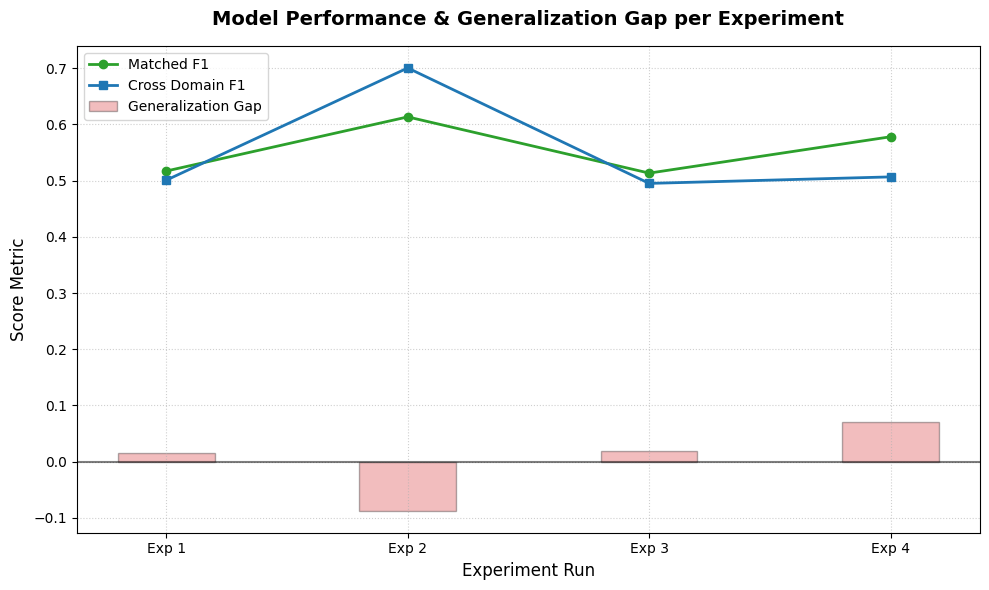

In [ ]:
import matplotlib.pyplot as plt

experiments = ['Exp 1', 'Exp 2', 'Exp 3', 'Exp 4']
matched_f1 = [0.516994, 0.613295, 0.513293, 0.577993]
cross_f1 = [0.500718, 0.700350, 0.494997, 0.506585]
gap = [0.016276, -0.087055, 0.018296, 0.071408]

plt.figure(figsize=(10, 6))

plt.plot(experiments, matched_f1, marker='o', linewidth=2, label='Matched F1', color='#2ca02c')
plt.plot(experiments, cross_f1, marker='s', linewidth=2, label='Cross Domain F1', color='#1f77b4')
plt.bar(experiments, gap, alpha=0.3, width=0.4, label='Generalization Gap', color='#d62728', edgecolor='black')

plt.title('Model Performance & Generalization Gap per Experiment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experiment Run', fontsize=12)
plt.ylabel('Score Metric', fontsize=12)
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

This cell displays a bar chart illustrating the reduction in the dataset's row count as it progresses through the cleaning pipeline (raw data, after 'Slowloris' filter, and after deduplication).

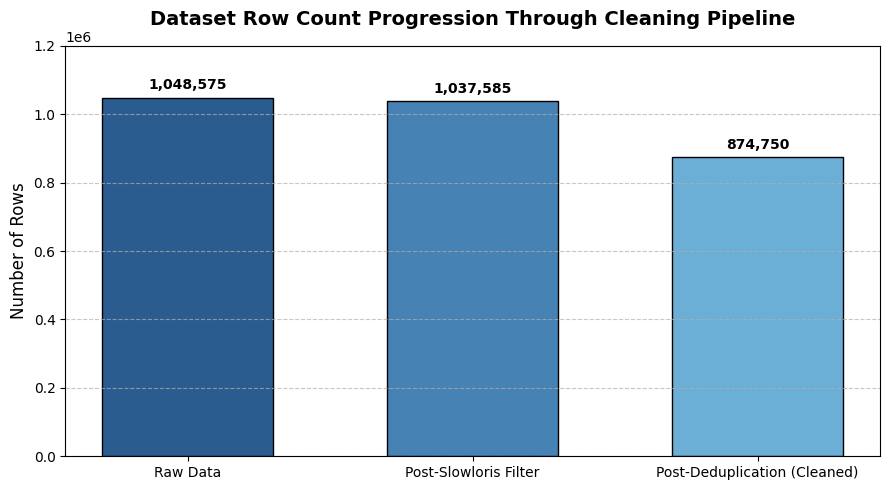

In [ ]:
import matplotlib.pyplot as plt

steps = ['Raw Data', 'Post-Slowloris Filter', 'Post-Deduplication (Cleaned)']
counts = [1048575, 1037585, 874750]

plt.figure(figsize=(9, 5))
bars = plt.bar(steps, counts, color=['#2b5c8f', '#4682b4', '#6baed6'], edgecolor='black', width=0.6)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 15000, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Row Count Progression Through Cleaning Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Rows', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1200000)
plt.tight_layout()
plt.show()

This cell presents a line and scatter plot summarizing the F1-Score, False Positive Rate (FPR), and False Negative Rate (FNR) for the best training/testing combinations found in each experiment.

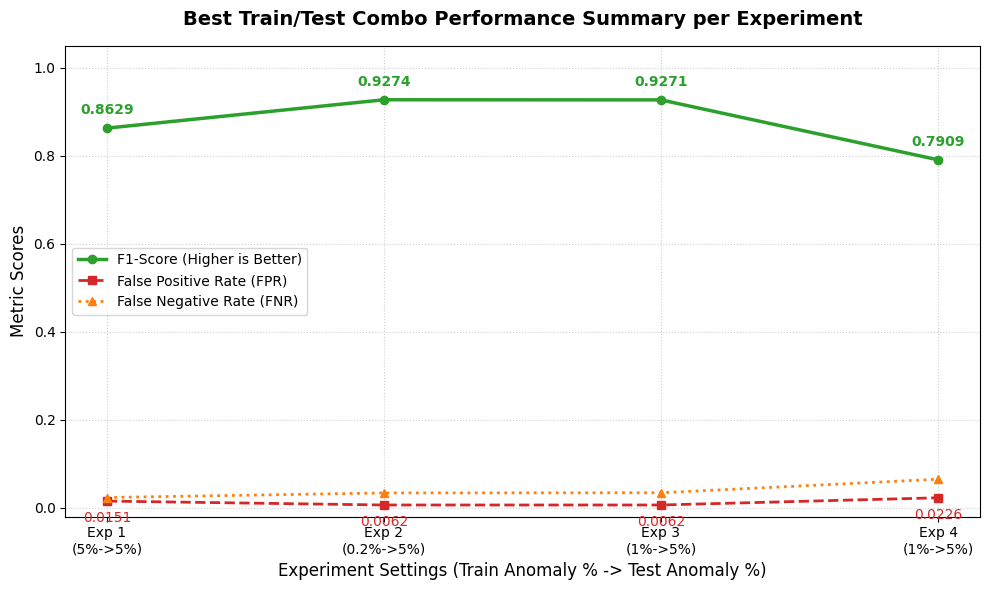

In [ ]:
import matplotlib.pyplot as plt

# Data from best performance combos
experiments = ['Exp 1\n(5%->5%)', 'Exp 2\n(0.2%->5%)', 'Exp 3\n(1%->5%)', 'Exp 4\n(1%->5%)']
f1_scores = [0.8629, 0.9274, 0.9271, 0.7909]
fpr_values = [0.0151, 0.0062, 0.0062, 0.0226]
fnr_values = [0.0232, 0.0336, 0.0340, 0.0648]

plt.figure(figsize=(10, 6))

# Plotting F1-Score on primary y-axis
plt.plot(experiments, f1_scores, marker='o', color='#2ca02c', linewidth=2.5, label='F1-Score (Higher is Better)')

# Plotting Error Rates (FPR & FNR)
plt.plot(experiments, fpr_values, marker='s', color='#d62728', linestyle='--', linewidth=2, label='False Positive Rate (FPR)')
plt.plot(experiments, fnr_values, marker='^', color='#ff7f0e', linestyle=':', linewidth=2, label='False Negative Rate (FNR)')

# Adding Value Labels onto the Graph
for i, txt in enumerate(f1_scores):
    plt.annotate(f'{txt:.4f}', (experiments[i], f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#2ca02c')
for i, txt in enumerate(fpr_values):
    plt.annotate(f'{txt:.4f}', (experiments[i], fpr_values[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='#d62728')

plt.title('Best Train/Test Combo Performance Summary per Experiment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experiment Settings (Train Anomaly % -> Test Anomaly %)', fontsize=12)
plt.ylabel('Metric Scores', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center left')
plt.ylim(-0.02, 1.05)  # Keeps space open at top for clarity

plt.tight_layout()
plt.show()

ad mark down cell abov each code cell